In [40]:
using QuantumOptics
using IonSim
using Pkg;
Pkg.build("IJulia")
Pkg.add("DSP")
Pkg.add("LaTeXStrings")
Pkg.add("Plots")

using DSP: periodogram
using LaTeXStrings
using Plots
gr() 

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building IJulia → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/102656c4efc9737f892e1bca7e66ae374c650740/build.log`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Plots.GRBackend()

In [41]:
# set some plot configs
default(
    fontfamily="Palatino",
    guidefontsize=20,
    titlefontsize=20,
    tickfontsize=14,
    linewidth=2,
    gridalpha=0.25,
    gridstyle=:dash,
    grid=true,
    size=(1600, 800),
    margin=8Plots.mm,  # extra room so the large fonts don't get clipped
)

# lightweight PyPlot-style shim over Plots.jl so `plt.plot(...)` etc. still work
# (pure Julia — no PyCall/PyPlot involved, so it avoids the GC-finalizer segfault)
module plt
    import Plots

    const _linestyles = Dict(
        "-" => :solid, "solid" => :solid,
        "--" => :dash, "dashed" => :dash,
        ":" => :dot, "dotted" => :dot,
        "-." => :dashdot, "dashdot" => :dashdot,
    )
    const _loc = Dict(
        0 => :best, 1 => :topright, 2 => :topleft, 3 => :bottomleft, 4 => :bottomright,
        5 => :right, 6 => :left, 7 => :bottom, 8 => :top, 9 => :outertop, 10 => :outertop,
    )
    const _active = Ref(false)

    function plot(args...; ls=nothing, zorder=nothing, kwargs...)
        extra = ls === nothing ? NamedTuple() : (linestyle = get(_linestyles, ls, :solid),)
        p = _active[] ? Plots.plot!(args...; kwargs..., extra...) : Plots.plot(args...; kwargs..., extra...)
        _active[] = true
        return p
    end

    text(x, y, s; fontsize=12, kwargs...) = Plots.annotate!(x, y, Plots.text(s, fontsize); kwargs...)
    legend(; loc=nothing, framealpha=nothing, kwargs...) =
        Plots.plot!(legend = loc === nothing ? :best : get(_loc, loc, :best))
    xlim(a, b) = Plots.xlims!(a, b)
    ylim(a, b) = Plots.ylims!(a, b)
    xlabel(s) = Plots.xlabel!(s)
    ylabel(s) = Plots.ylabel!(s)
    title(s) = Plots.title!(s)
    tight_layout(args...; kwargs...) = Plots.plot!(margin=8Plots.mm)  # closest Plots.jl equivalent
    function show()
        p = Plots.current()
        _active[] = false
        return p
    end
end

# guarantee a fresh figure every cell, even if the previous cell errored
# out before calling plt.show() (mirrors what PyPlot.jl does for IJulia)
IJulia.push_preexecute_hook() do
    plt._active[] = false
end

2-element Vector{Function}:
 #2 (generic function with 1 method)
 #186 (generic function with 1 method)

In [42]:
# Setup system
ca = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
laser = Laser()
νᵣ = 3 * 1e6  # radial trap frequency
νₐ = 1e6  # axial trap frequency — kept distinct from νᵣ so the two modes
            # aren't frequency-degenerate (degenerate modes + this symmetric
            # wavevector couple to both modes identically, capping any single
            # sideband transfer at 50% — see the (x̂+ẑ)/√2 wavevector below)
chain = LinearChain(
        ions=[ca],
        comfrequencies=(x=νᵣ, y=νᵣ, z=νₐ), 
        selectedmodes=(x=[1], z=[1]),
        N = 5
    )
chamber = Chamber(iontrap=chain, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser])
# set laser parameters
wavelength_from_transition!(laser, ca, ("S", "D"), chamber)
polarization!(laser, ẑ)
wavevector!(laser, (x̂ + ẑ)/√2)
# set carrier transition Rabi frequency to 500 kHz
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber);

In [43]:
axial = zmodes(chamber)[1]
radial = xmodes(chamber)[1]

ρᵢ_ion = dm(ca["S"])
ρᵢ_axial = thermalstate(axial, 0.5)
ρᵢ_radial = thermalstate(radial, 0.5)
# Set initial state to ρᵢ = |↓, n̄ᵣ=0.5, n̄ₐ=0.5⟩
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial;  

In [44]:
tspan = 0:10:400
fout(t, ρ) = real(expect(ionprojector(chamber, "D"), ρ))
J = (-dm(ca["S"]) + dm(ca["D"])) ⊗ one(radial) ⊗ one(axial)  # Collapse operator
γ = 1e4 * 1e-6 

# Scan laser detuning
Δlist = range(νₐ, stop=2νᵣ + 1e5, length=10)
exclist = []
for Δ in Δlist
    detuning!(laser, Δ)
    h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
    _, sol = timeevolution.master_dynamic(tspan, ρᵢ, (t, ρ) -> (h(t, ρ), [J], [J], [γ]), fout=fout)
    push!(exclist, real(sol[end]))
end 

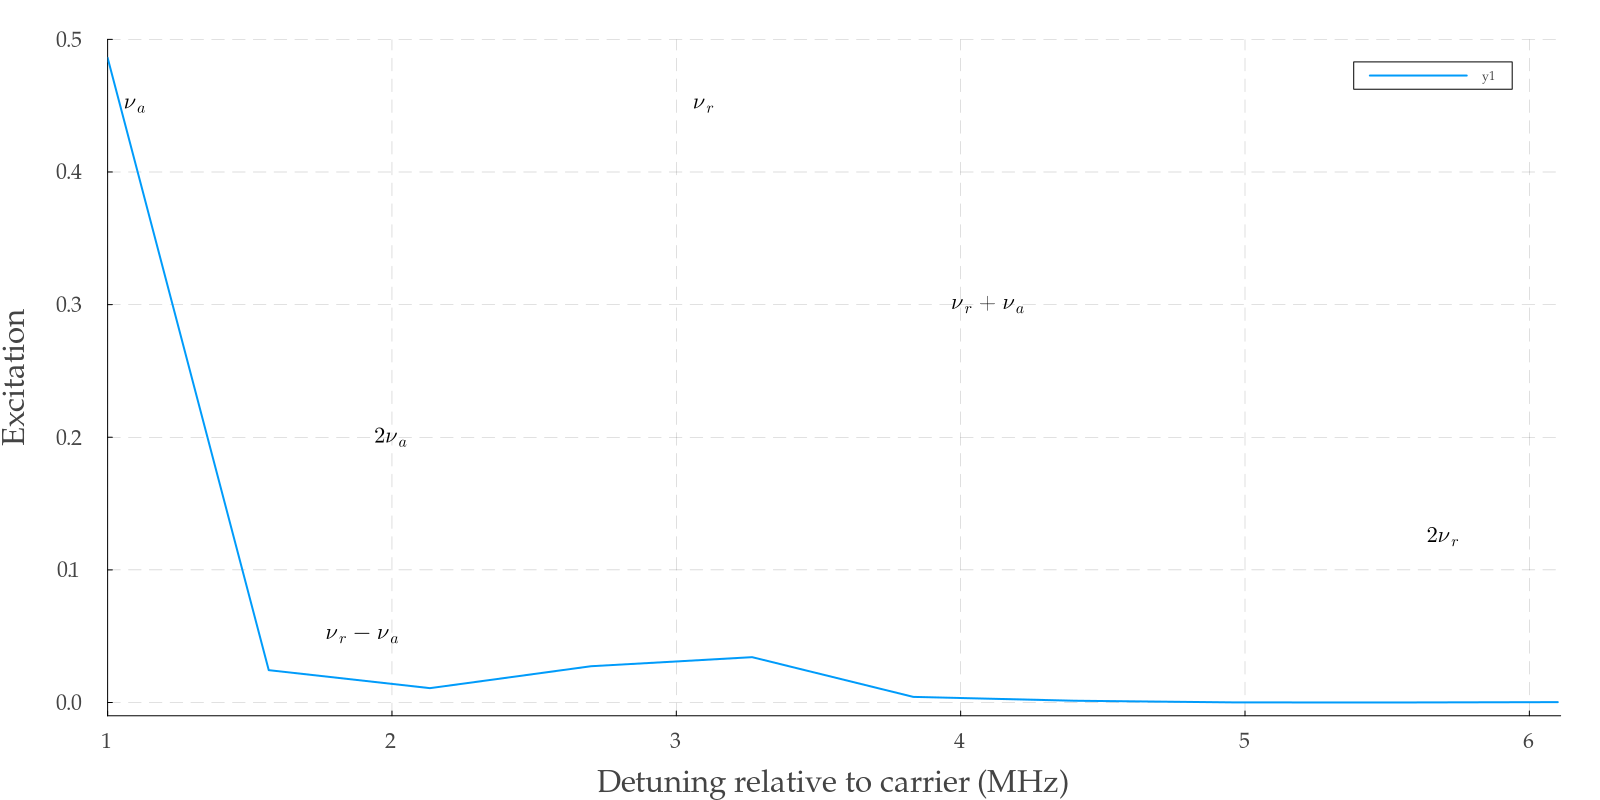

In [45]:
plt.plot(@.((Δlist) / 1e6) , exclist)
plt.text(νₐ/1e6 + 0.1, 0.45, L"\nu_a", fontsize=15)
plt.text(νᵣ/1e6 + 0.1, 0.45, L"\nu_r", fontsize=15)
plt.text(2νₐ/1e6, 0.2, L"2\nu_a", fontsize=15)
plt.text(2νᵣ/1e6 - 0.3, 0.125, L"2\nu_r", fontsize=15)
plt.text((νᵣ + νₐ)/1e6 + 0.1, 0.3, L"\nu_r + \nu_a", fontsize=15)
plt.text((νᵣ - νₐ)/1e6 - 0.1, 0.05, L"\nu_r - \nu_a", fontsize=15)
plt.xlim((Δlist[1]) / 1e6, (Δlist[end]) / 1e6 + 0.01)
plt.ylim(-0.01, 0.5)
plt.xlabel("Detuning relative to carrier (MHz)")
plt.ylabel("Excitation")
plt.show()

In [46]:
# set carrier transition Rabi frequency to 1 MHz
intensity_from_rabifrequency!(1, 1e6, 1, ("S", "D"), chamber)
detuning!(laser, frequency(axial))
modecutoff!(axial, 10)
modecutoff!(radial, 10)

h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1e4, displacement="truncated", time_dependent_eta=false)
tspan = 0:0.25:800

# Set initial state to |↓, n̄ᵣ=0, n̄ₐ=1.5⟩ and solve
ρᵢ_axial = thermalstate(axial, 1.5)
ρᵢ_radial = thermalstate(radial, 0)
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial  
tout_ax, sol_ax = timeevolution.schroedinger_dynamic(tspan, ρᵢ, h, fout=fout)

# Set initial state to |↓, n̄ᵣ=1.5, n̄ₐ=0⟩ and solve
ρᵢ_axial = thermalstate(axial, 0)
ρᵢ_radial = thermalstate(radial, 1.5)
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial  
tout_rad, sol_rad = timeevolution.schroedinger_dynamic(tspan, ρᵢ, h, fout=fout);

println("length(tout_ax)=", length(tout_ax), " length(sol_ax)=", length(sol_ax))
println("length(tout_rad)=", length(tout_rad), " length(sol_rad)=", length(sol_rad))

length(tout_ax)=3201 length(sol_ax)=3201
length(tout_rad)=3201 length(sol_rad)=3201


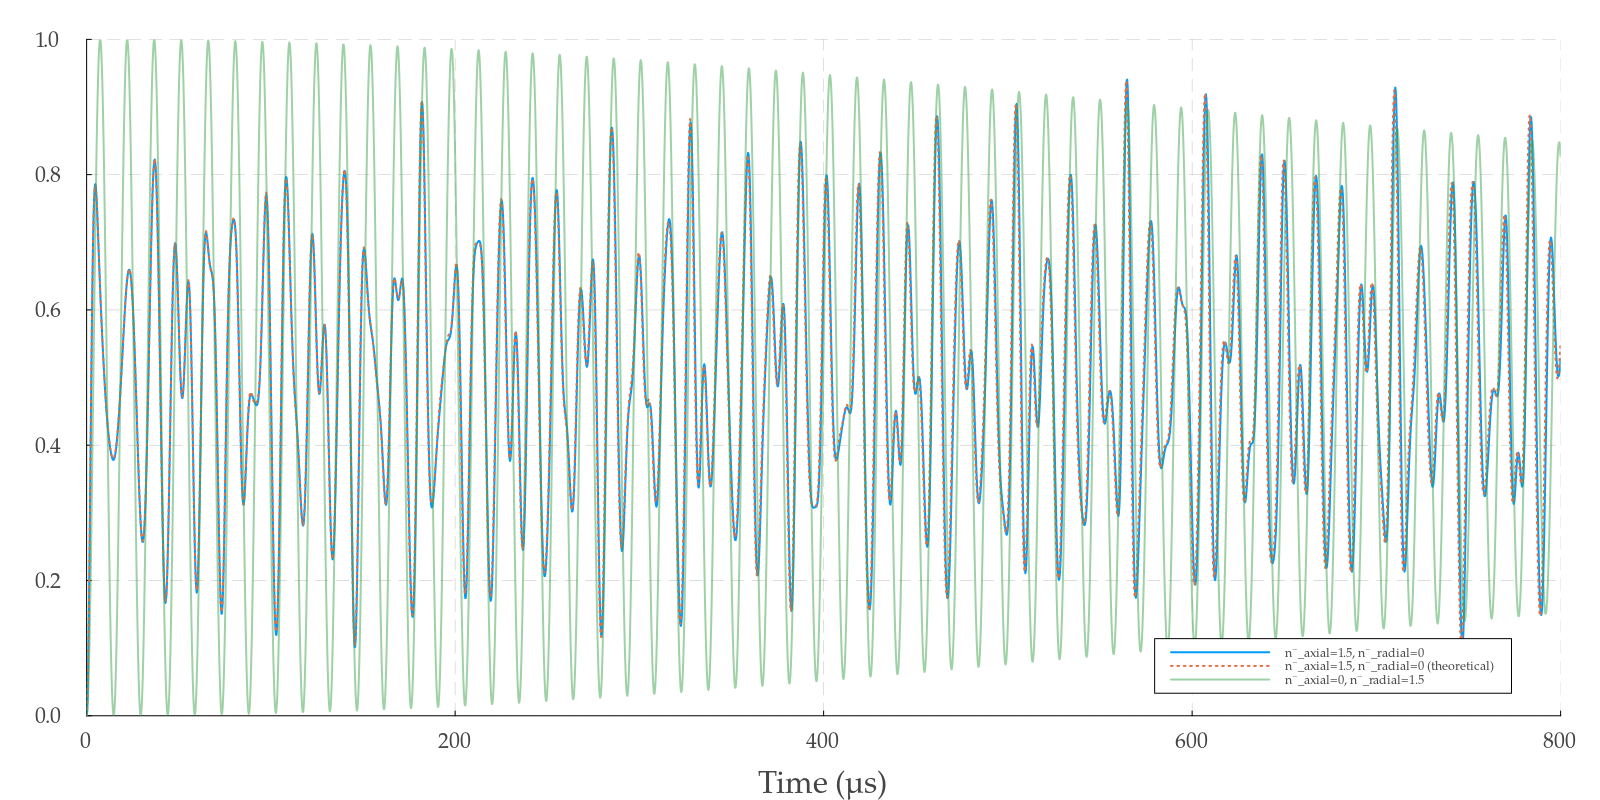

In [47]:
theory = only.(analytical.rabiflop.(tout_ax, 1, lambdicke(axial, ca, laser), 1.5, s=1))

plt.plot(tout_ax, sol_ax, label="n̄_axial=1.5, n̄_radial=0")
plt.plot(tout_ax, theory, ls="dotted", label="n̄_axial=1.5, n̄_radial=0 (theoretical)")
plt.plot(tout_rad, sol_rad, alpha=0.5, label="n̄_axial=0, n̄_radial=1.5", zorder=-1)
plt.legend(loc=4, framealpha=1)
plt.ylim(0, 1)
plt.xlim(0, tout_ax[end])
plt.xlabel("Time (μs)")
plt.show()

In [48]:
# Single pulse tuned to the sum-frequency (Δ = νᵣ + νₐ): one tone couples both
# the axial and radial modes at once (a joint two-phonon "blue" sideband).
# Starting from |↓, n_axial=0, n_radial=0⟩, the pulse drives |↓,0,0⟩ → |↑,1,1⟩,
# so both mode populations should rise together as the ion excites.
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)  # carrier Rabi frequency 500 kHz
detuning!(laser, νᵣ + νₐ)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

h_sum = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_sum = 0:1:1000  # μs — extend this if you don't see a full oscillation

# Start from the ground state of everything: |↓, n_axial=0, n_radial=0⟩
ρ₀ = dm(ca["S"]) ⊗ thermalstate(radial, 0) ⊗ thermalstate(axial, 0)

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_sum(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_sum, sol_sum = timeevolution.schroedinger_dynamic(tspan_sum, ρ₀, h_sum, fout=fout_sum)

P_D      = [s[1] for s in sol_sum]
n_axial  = [s[2] for s in sol_sum]
n_radial = [s[3] for s in sol_sum]

1001-element Vector{Float64}:
 0.0
 1.7945970428200463e-5
 7.18488351455477e-5
 0.00016177456885899425
 0.0002876678160462775
 0.0004496227876914673
 0.0006475084929189895
 0.0008814501820632799
 0.0011512736358767236
 0.0014570996034348267
 0.0017987990580079836
 0.002176394848166
 0.0025898739343355446
 ⋮
 0.7775228477942772
 0.7809127559959317
 0.784281280216109
 0.7876281602481395
 0.7909531585174473
 0.7942560279254461
 0.7975365179184417
 0.8007943845147016
 0.8040293908977164
 0.8072413067126556
 0.8104299039846098
 0.8135949587838383

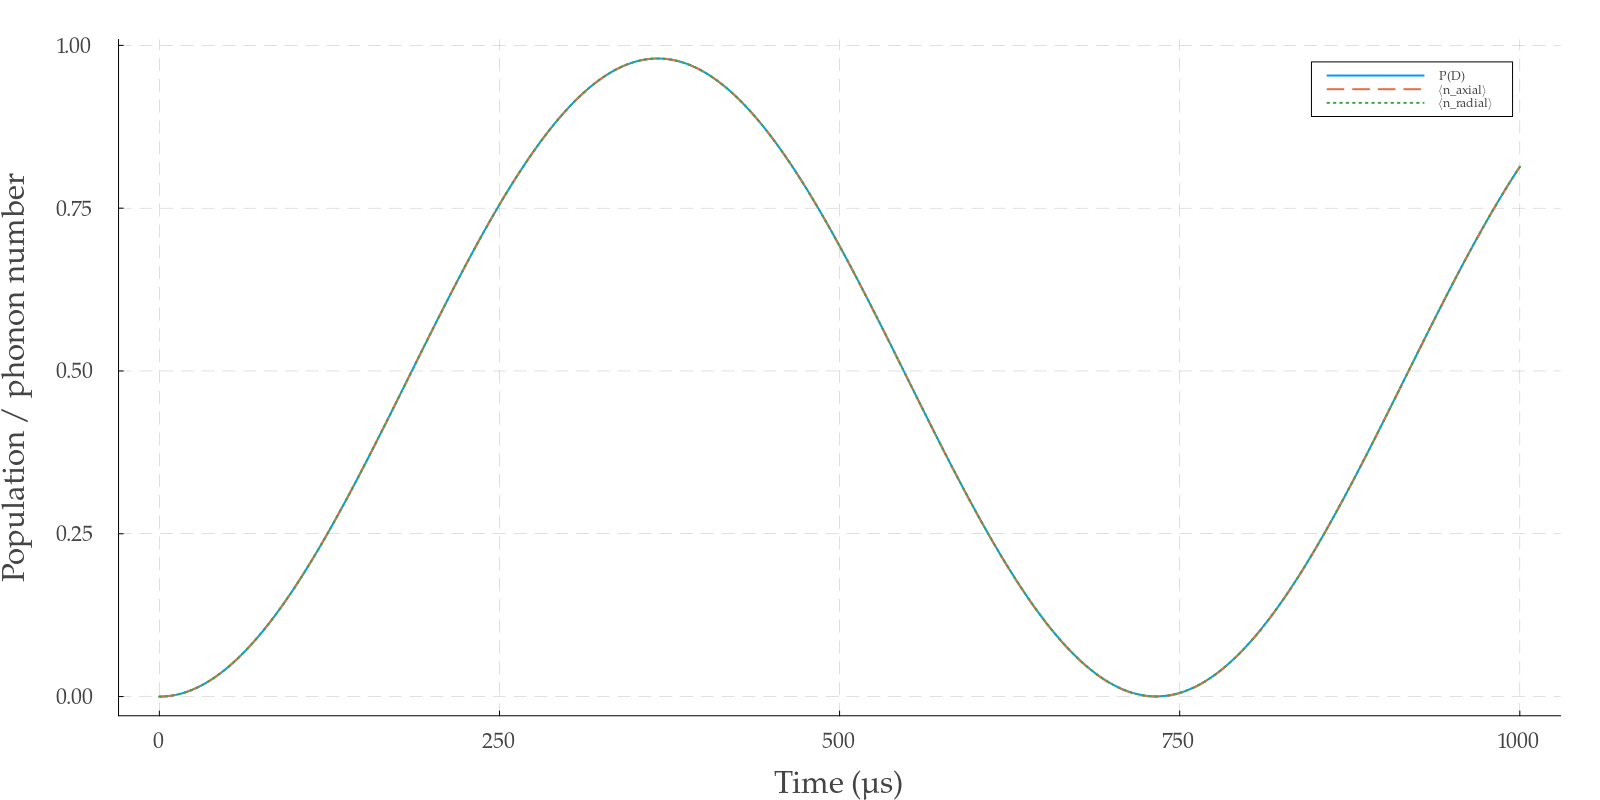

In [49]:
plt.plot(tout_sum, P_D, label="P(D)")
plt.plot(tout_sum, n_axial, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_sum, n_radial, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [50]:
# Detuning scan starting from 1 phonon in BOTH modes: |↓, n_axial=1, n_radial=1⟩
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

tspan_scan = 0:10:400
ρ₀_scan = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)
J = (-dm(ca["S"]) + dm(ca["D"])) ⊗ one(radial) ⊗ one(axial)  # same dephasing as the first scan
γ = 0

fout_scan(t, ρ) = (
    real(expect(ionprojector(chamber, "D"), ρ)),
    real(expect(n_axial_op, ρ)),
    real(expect(n_radial_op, ρ)),
)

Δlist_scan = range(0, stop=-2νᵣ - 1e5, length=50)
P_D_scan = Float64[]
n_axial_scan = Float64[]
n_radial_scan = Float64[]

for Δ in Δlist_scan
    detuning!(laser, Δ)
    h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
    _, sol = timeevolution.master_dynamic(tspan_scan, ρ₀_scan, (t, ρ) -> (h(t, ρ), [J], [J], [γ]), fout=fout_scan)
    push!(P_D_scan, sol[end][1])
    push!(n_axial_scan, sol[end][2])
    push!(n_radial_scan, sol[end][3])
end

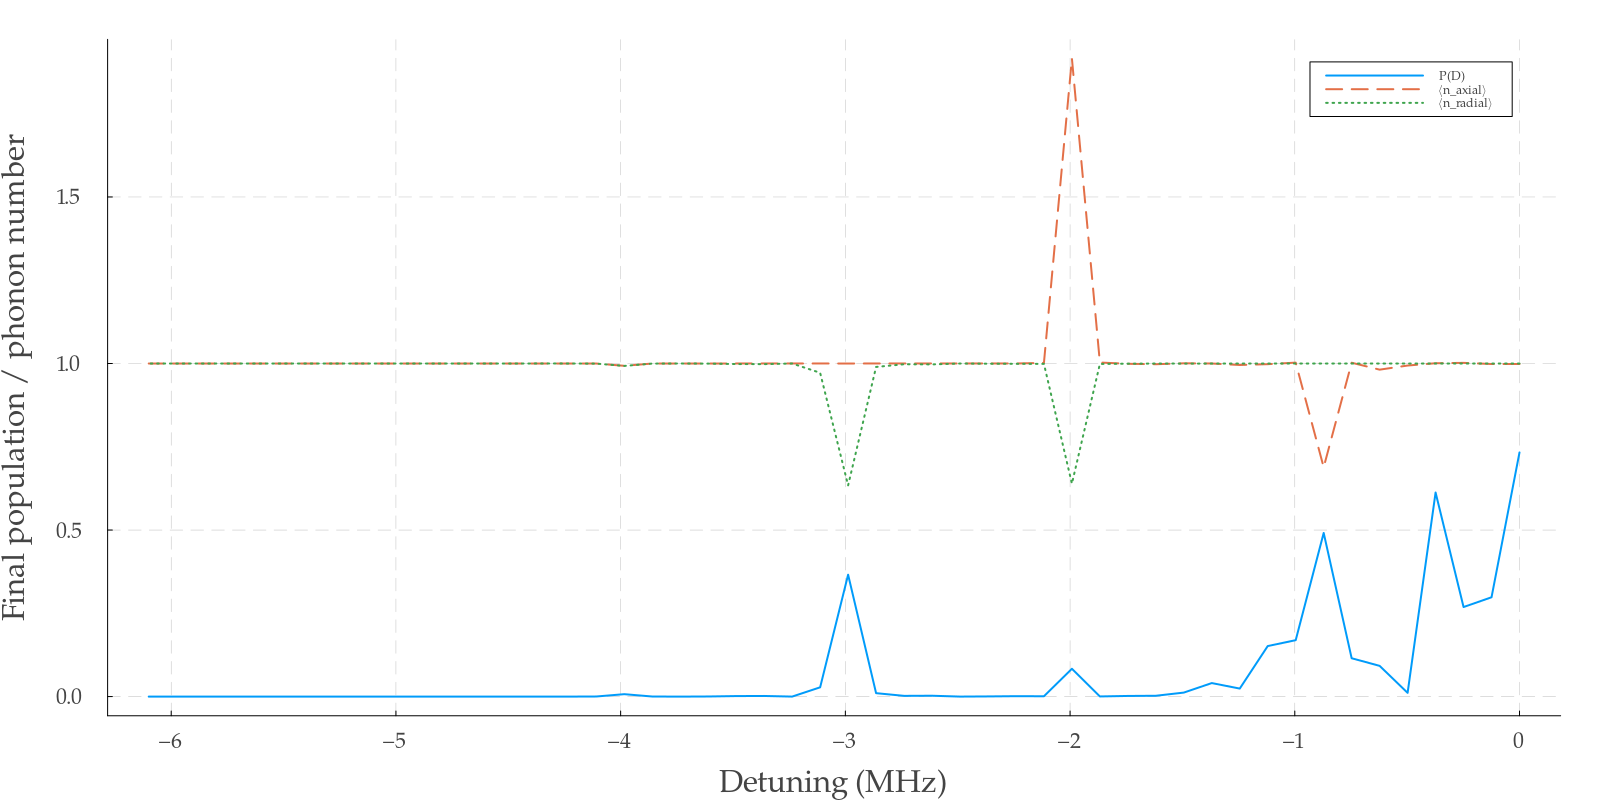

In [51]:
plt.plot(Δlist_scan ./ 1e6, P_D_scan, label="P(D)")
plt.plot(Δlist_scan ./ 1e6, n_axial_scan, ls="dashed", label="⟨n_axial⟩")
plt.plot(Δlist_scan ./ 1e6, n_radial_scan, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Detuning (MHz)")
plt.ylabel("Final population / phonon number")
plt.show()

In [52]:
# Pure coherent Rabi oscillation at ONE fixed detuning — no dephasing, so you
# see the real oscillation the detuning scan was smoothing over.
# Δ = -νᵣ: the radial red sideband only, starting from |↓, n_axial=1, n_radial=1⟩.
Δ_fixed = -(νᵣ)
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
detuning!(laser, Δ_fixed)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

h_fixed = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)
tspan_fixed = 0:5:100  # μs — extend if you don't see a full oscillation

ρ₀_fixed = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_fixed(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_fixed, sol_fixed = timeevolution.schroedinger_dynamic(tspan_fixed, ρ₀_fixed, h_fixed, fout=fout_fixed)

P_D_fixed      = [s[1] for s in sol_fixed]
n_axial_fixed  = [s[2] for s in sol_fixed]
n_radial_fixed = [s[3] for s in sol_fixed]

21-element Vector{Float64}:
 1.0
 0.9079322622475986
 0.6656350275043458
 0.3623398300560634
 0.10974214949604744
 0.0008669361434650321
 0.07581002639662608
 0.3069719152005689
 0.6092219039885892
 0.8712494377990082
 0.9965568085434416
 0.9389966539299707
 0.7197668098740878
 0.41960372571917415
 0.14904940433832206
 0.007741736103924977
 0.047720564215442095
 0.254262783924107
 0.5513044571909225
 0.8294531161106274
 0.9862740754269445

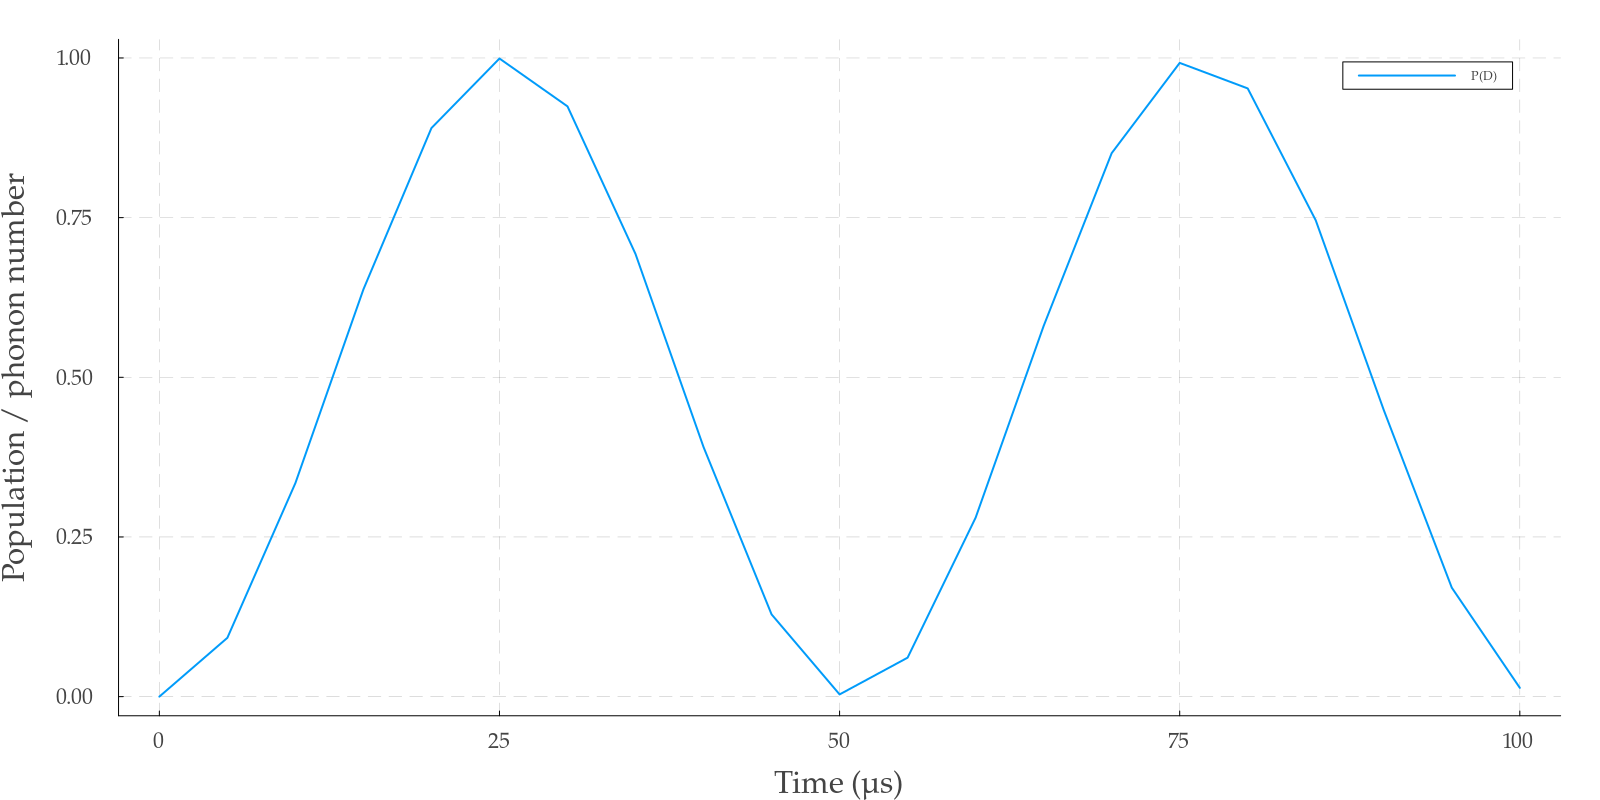

In [53]:
plt.plot(tout_fixed, P_D_fixed, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

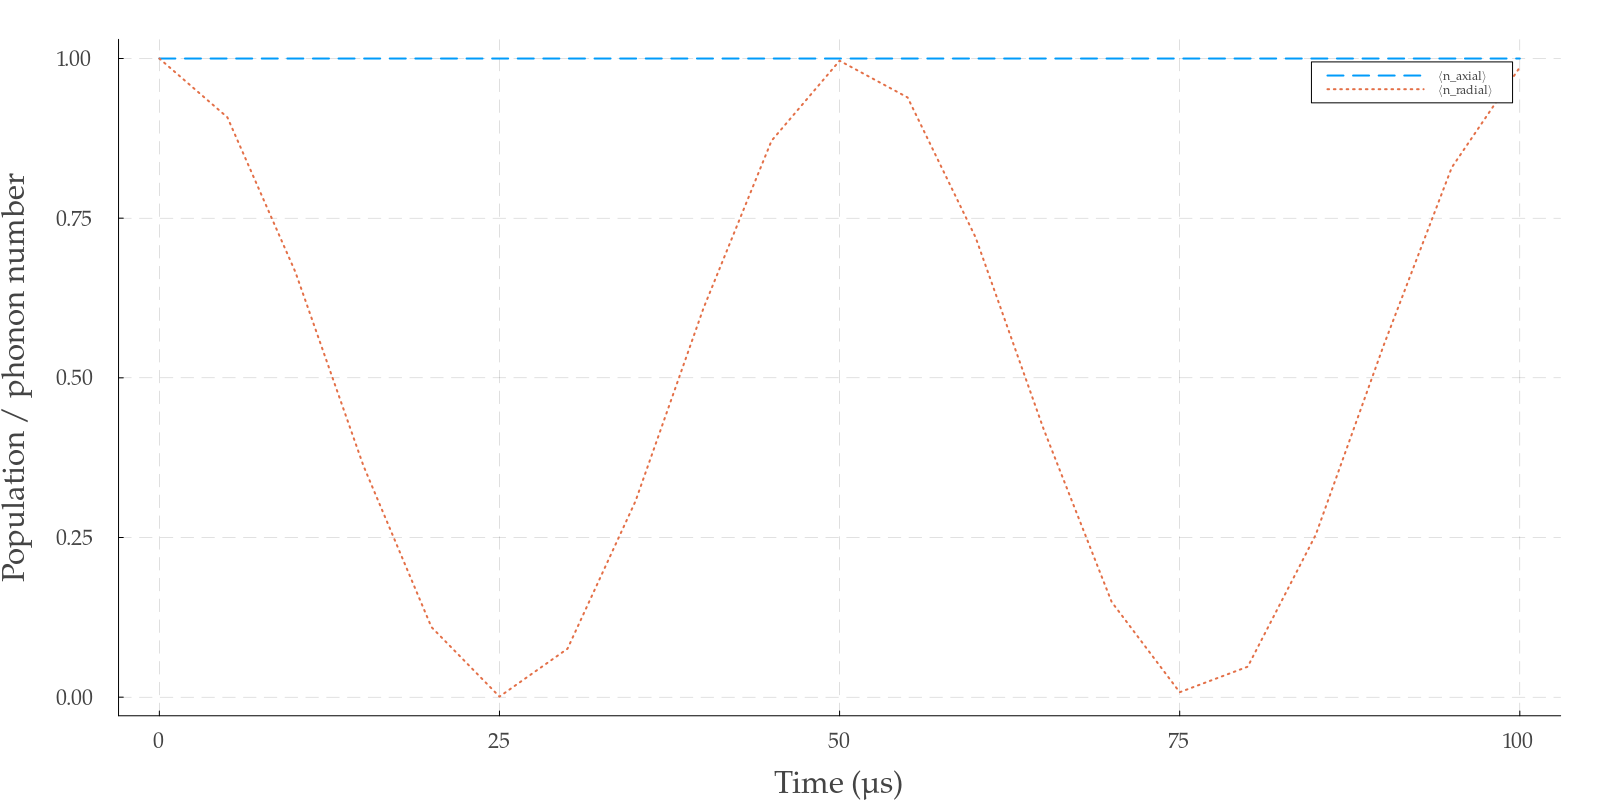

In [54]:
plt.plot(tout_fixed, n_axial_fixed, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_fixed, n_radial_fixed, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [55]:
# Pure coherent Rabi oscillation at ONE fixed detuning — no dephasing, so you
# see the real oscillation the detuning scan was smoothing over.
# Δ = -(νᵣ + νₐ): the joint RED sideband — removes a phonon from BOTH modes
# together while exciting the ion, starting from |↓, n_axial=1, n_radial=1⟩.
Δ_fixed = -(νᵣ + νₐ)
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
detuning!(laser, Δ_fixed)
modecutoff!(radial, 5)

h_fixed = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_fixed = 0:5:1000  # μs — extend if you don't see a full oscillation

ρ₀_fixed = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_fixed(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_fixed, sol_fixed = timeevolution.schroedinger_dynamic(tspan_fixed, ρ₀_fixed, h_fixed, fout=fout_fixed)

P_D_fixed      = [s[1] for s in sol_fixed]
n_axial_fixed  = [s[2] for s in sol_fixed]
n_radial_fixed = [s[3] for s in sol_fixed]

201-element Vector{Float64}:
 1.0
 0.9995503738226399
 0.9982011954903875
 0.9959548750009142
 0.9928154701199658
 0.9887887818782596
 0.9838822262782002
 0.9781048187322741
 0.9714671546049793
 0.9639814072500712
 0.9556613897710368
 0.9465224198720045
 0.9365811804541754
 ⋮
 0.3887703051829078
 0.36853490365023744
 0.34855971055889984
 0.3288814028671033
 0.3095361714585869
 0.2905596088826994
 0.2719865431005688
 0.25385114625586286
 0.23618675923931756
 0.21902582194413706
 0.20239992589181133
 0.18633959055987162

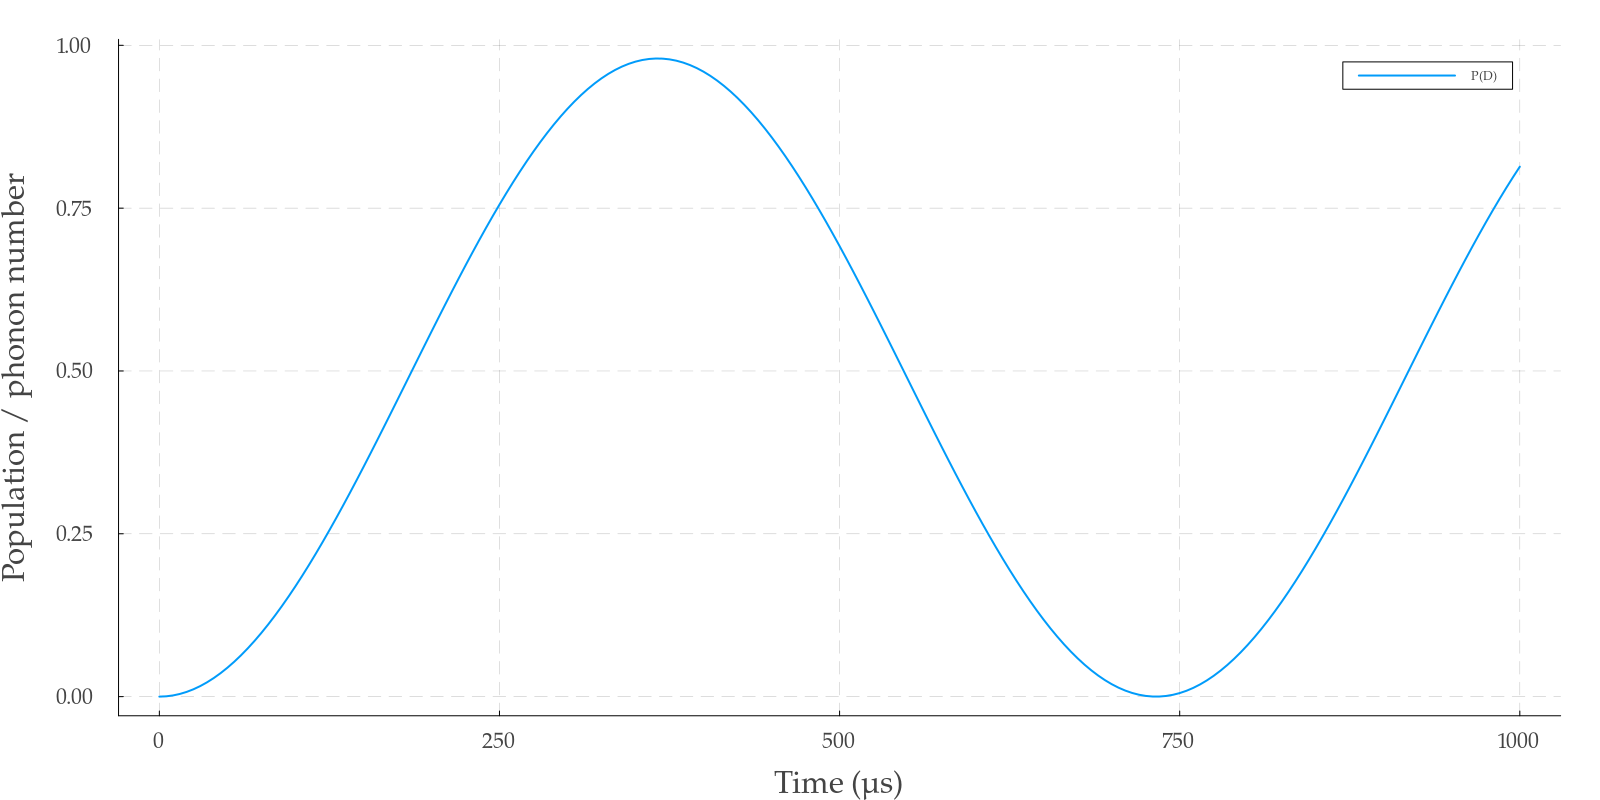

In [56]:
plt.plot(tout_fixed, P_D_fixed, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()


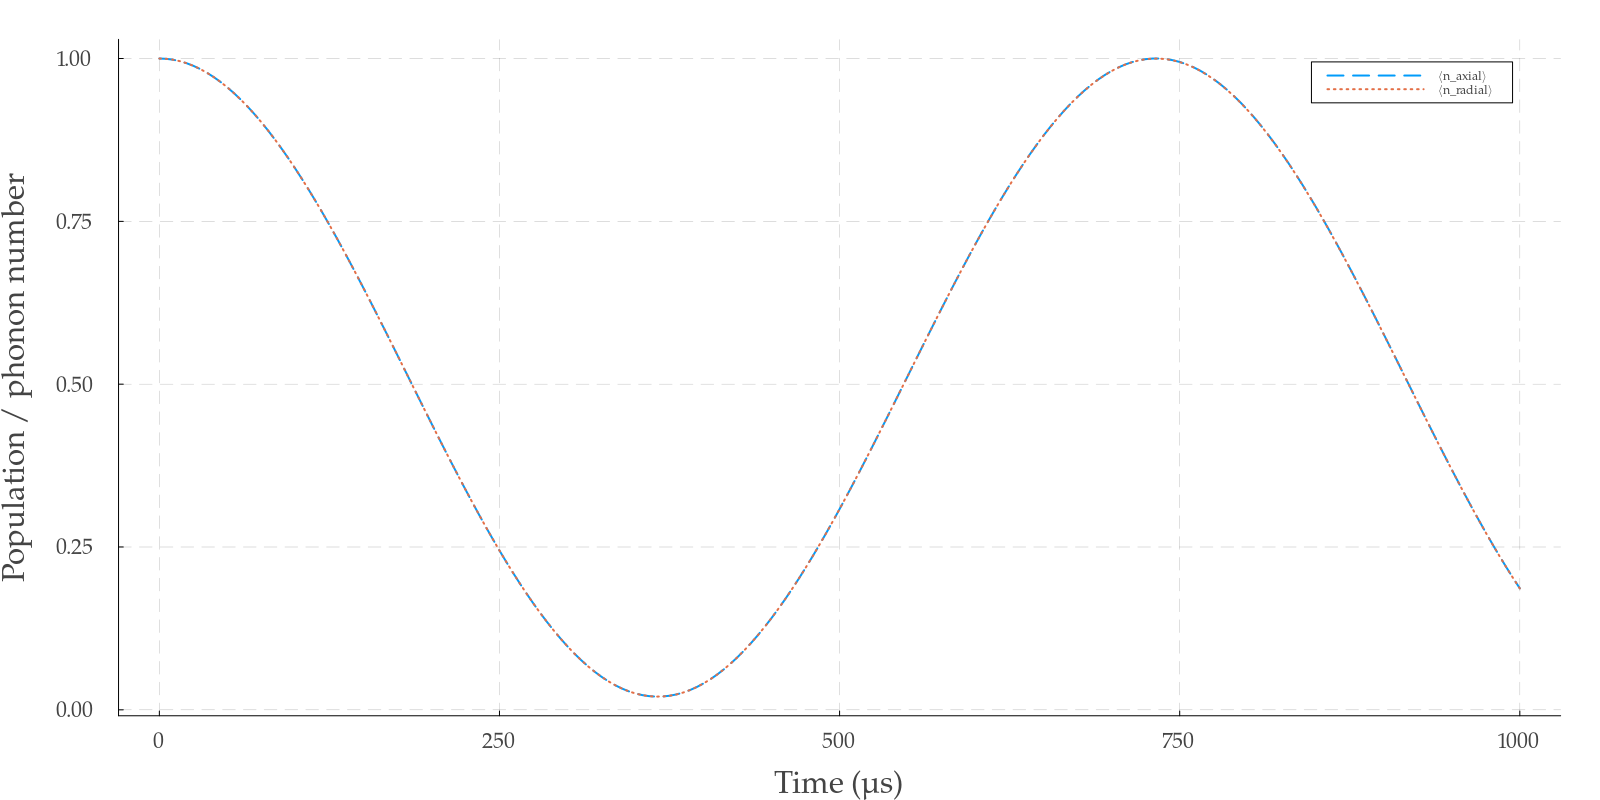

In [57]:
plt.plot(tout_fixed, n_axial_fixed, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_fixed, n_radial_fixed, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [58]:
# Same idea as above, but for TWO RADIAL modes instead of axial+radial.
# A single ion only has one radial normal mode, so this needs its own 2-ion
# chain — self-contained setup below, separate from the single-ion `ca`/
# `chamber` used earlier, so it doesn't disturb anything above.
ca1_2r = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
ca2_2r = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
laser_2r = Laser()
chain_2r = LinearChain(
    ions=[ca1_2r, ca2_2r],
    comfrequencies=(x=√14 * 1e6, y=√14 * 1e6, z=1.5e6),
    selectedmodes=(x=[1, 2],),  # both radial normal modes: 1=in-phase ("COM"), 2=out-of-phase ("stretch")
)
chamber_2r = Chamber(iontrap=chain_2r, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_2r])
wavelength_from_transition!(laser_2r, ca1_2r, ("S", "D"), chamber_2r)
polarization!(laser_2r, ẑ)
wavevector!(laser_2r, (x̂ + ẑ)/√2)
pointing!(laser_2r, [(1, 1.0)])  # only ion 1 is addressed; ion 2 is a motional spectator
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber_2r)

mode1_2r, mode2_2r = xmodes(chamber_2r)
modecutoff!(mode1_2r, 5)
modecutoff!(mode2_2r, 5)

# Δ = -(mode1_freq + mode2_freq): joint RED sideband — removes a phonon from
# BOTH radial modes together while exciting ion 1, starting from
# |↓, n_mode1=1, n_mode2=1⟩. No dephasing (schroedinger_dynamic), so this
# shows the real coherent oscillation directly.
Δ_fixed_2r = -(frequency(mode1_2r) + frequency(mode2_2r))
detuning!(laser_2r, Δ_fixed_2r)

h_fixed_2r = hamiltonian(chamber_2r, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_fixed_2r = 0:5:1500  # μs — extend if you don't see a full oscillation

ρ₀_fixed_2r = dm(ca1_2r["S"]) ⊗ dm(ca2_2r["S"]) ⊗ dm(fockstate(mode1_2r, 1)) ⊗ dm(fockstate(mode2_2r, 1))

n_mode1_op_2r = one(ca1_2r) ⊗ one(ca2_2r) ⊗ IonSim.number(mode1_2r) ⊗ one(mode2_2r)
n_mode2_op_2r = one(ca1_2r) ⊗ one(ca2_2r) ⊗ one(mode1_2r) ⊗ IonSim.number(mode2_2r)
PD_op_2r = ionprojector(chamber_2r, "D", "S")  # ion 1 excited, ion 2 (spectator) stays in S

fout_fixed_2r(t, ψ) = (
    real(expect(PD_op_2r, ψ)),
    real(expect(n_mode1_op_2r, ψ)),
    real(expect(n_mode2_op_2r, ψ)),
)

tout_fixed_2r, sol_fixed_2r = timeevolution.schroedinger_dynamic(tspan_fixed_2r, ρ₀_fixed_2r, h_fixed_2r, fout=fout_fixed_2r)

P_D_fixed_2r      = [s[1] for s in sol_fixed_2r]
n_mode1_fixed_2r  = [s[2] for s in sol_fixed_2r]
n_mode2_fixed_2r  = [s[3] for s in sol_fixed_2r]

301-element Vector{Float64}:
 1.0
 0.9999735278644187
 0.9998941146069651
 0.9997617690531405
 0.9995765055364111
 0.9993383431439353
 0.9990473062347635
 0.998703424882165
 0.9983067374985983
 0.9978572833668382
 0.9973551136684775
 0.9968002773523353
 0.9961928364267496
 ⋮
 0.007009875055079586
 0.006177132988876749
 0.005396722974866528
 0.004668637873619452
 0.003993046590417978
 0.0033699438469807245
 0.002799443151384557
 0.002281595507983839
 0.0018164252346508304
 0.0014040464126087442
 0.001044415542149114
 0.0007376620850514701

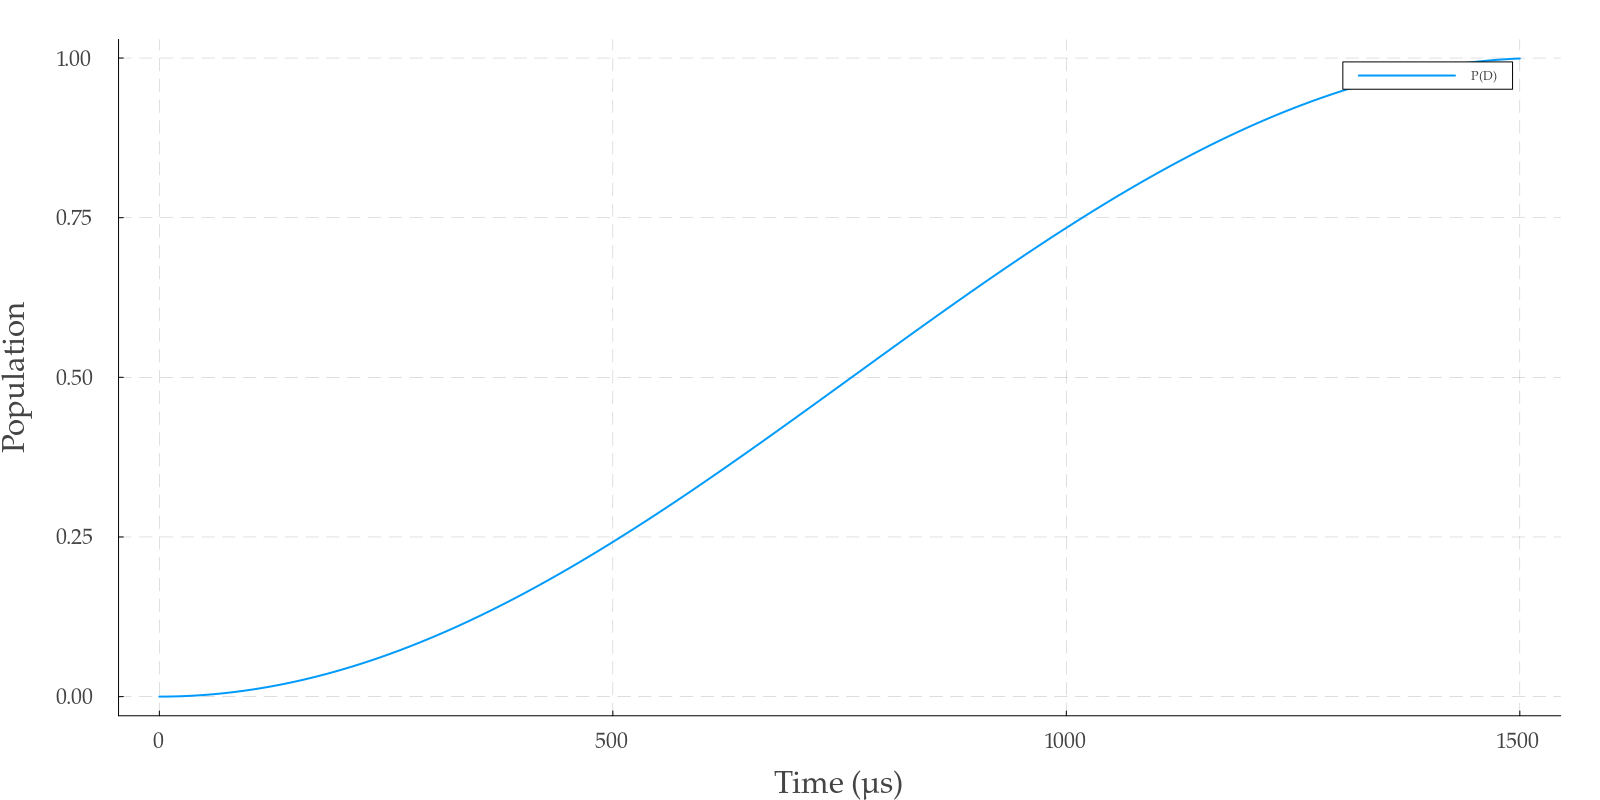

In [59]:
plt.plot(tout_fixed_2r, P_D_fixed_2r, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

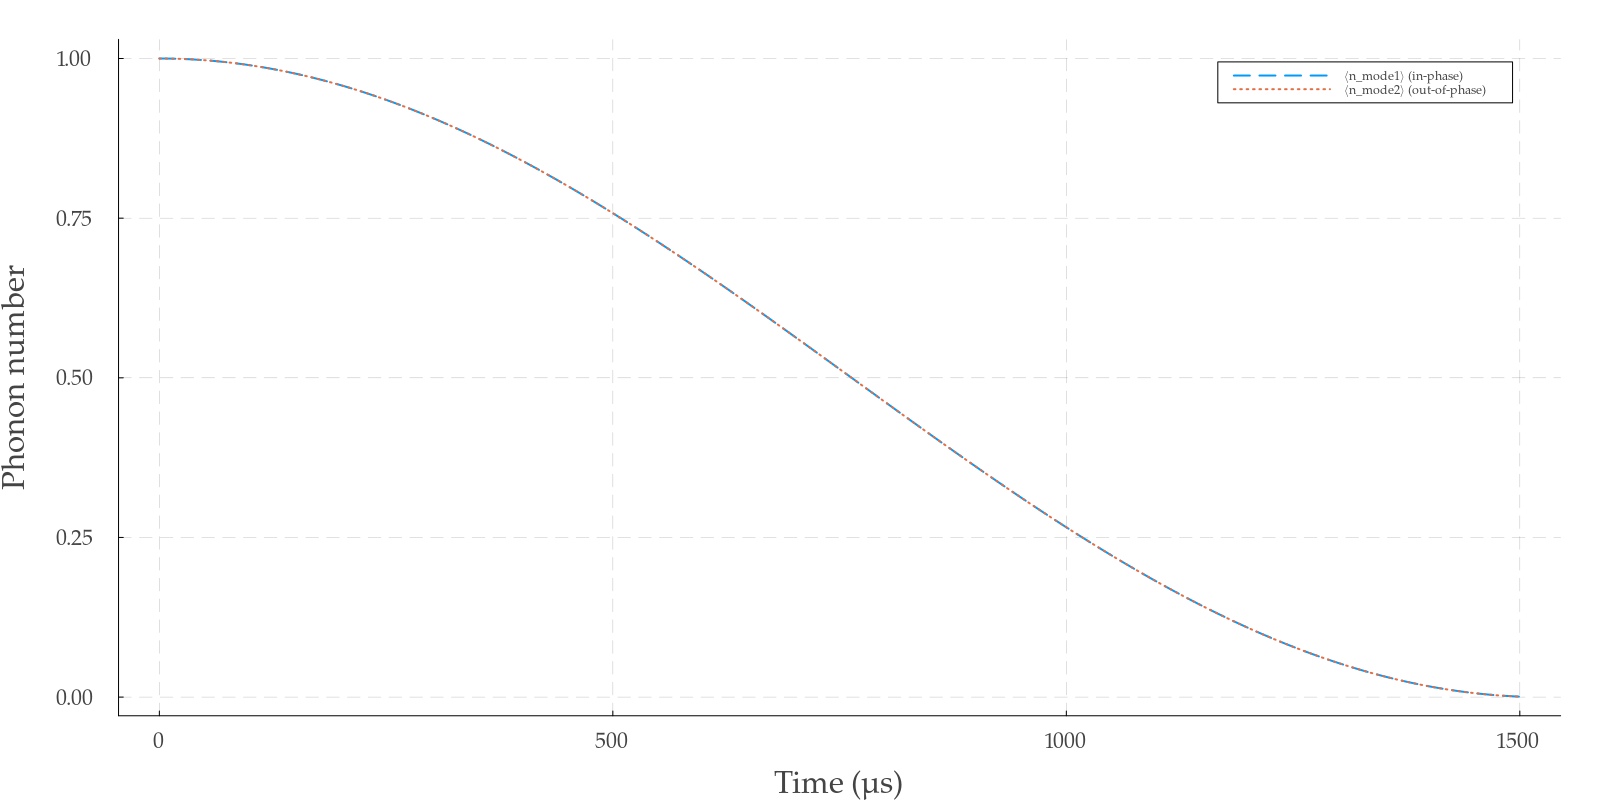

In [60]:
plt.plot(tout_fixed_2r, n_mode1_fixed_2r, ls="dashed", label="⟨n_mode1⟩ (in-phase)")
plt.plot(tout_fixed_2r, n_mode2_fixed_2r, ls="dotted", label="⟨n_mode2⟩ (out-of-phase)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()

In [61]:
# Import the custom 5-ion, 5-mode radial structure computed in
# Degenerate_Modes.ipynb (cell 13, `result_df` — a tweezer-perturbed chain
# where ion 3 is individually tweezed, breaking the usual symmetric mode
# structure). Values below are copied directly from that DataFrame row.
ions_deg = [Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")]) for _ in 1:5]

mode_freqs_deg = [3.117294e6, 2.985036e6, 2.984962e6, 2.936844e6, 2.934913e6]
mode_vecs_deg = [
    [-0.042220029114921794, -0.162427433217077, -0.971426577853401, -0.16242743321759626, -0.042220029114402084],
    [0.6421869890037765, 0.276747648307963, -0.14836852367094155, 0.27674764885379133, 0.642186990173329],
    [-0.6395330261024145, -0.30165793447008743, 1.3656089456365057e-10, 0.30165793395946217, 0.6395330249290007],
    [-0.3016579341615037, 0.6395330253950727, 3.621650927550304e-11, -0.6395330256363442, 0.30165793426804194],
    [-0.29293913971940183, 0.6301016331475053, -0.18524898116787497, 0.6301016329066403, -0.2929391396006231],
]

custom_modes_deg = [
    VibrationalMode(f, v, axis=x̂, N=5) for (f, v) in zip(mode_freqs_deg, mode_vecs_deg)
]

vm_deg = (x=custom_modes_deg, y=VibrationalMode[], z=VibrationalMode[])
# ion positions aren't given by result_df — only used here for B-field-gradient
# and addressing geometry (both effectively unused below), so a generic
# equilibrium spacing is fine; swap in real positions if you have them.
ionpositions_deg = linear_equilibrium_positions(5) .* 5e-6

chain_deg = LinearChain(ions_deg, vm_deg, ionpositions_deg)
laser_deg = Laser()
chamber_deg = Chamber(iontrap=chain_deg, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_deg])
wavelength_from_transition!(laser_deg, ions_deg[3], ("S", "D"), chamber_deg)
polarization!(laser_deg, ẑ)
wavevector!(laser_deg, x̂)
pointing!(laser_deg, [(3, 1.0)])  # address the tweezed ion, ion 3
intensity_from_rabifrequency!(1, 5e5, 3, ("S", "D"), chamber_deg)

xm_deg = xmodes(chamber_deg)
for (i, m) in enumerate(xm_deg)
    println("mode ", i, "  freq=", frequency(m) / 1e6, " MHz  η(ion 3)=", lambdicke(m, ions_deg[3], laser_deg))
end

mode 1  freq=3.117294 MHz  η(ion 3)=-0.05331724170586883
mode 2  freq=2.985036 MHz  η(ion 3)=-0.00832172888633056
mode 3  freq=2.984962 MHz  η(ion 3)=7.659554731150181e-12
mode 4  freq=2.936844 MHz  η(ion 3)=2.047918756147061e-12
mode 5  freq=2.934913 MHz  η(ion 3)=-0.010478636768856577


In [62]:
# Address ion 2 instead of ion 3, and look at what happens to mode 2 and
# mode 3 — these two are separated by only ~74 Hz (2.985036 MHz vs
# 2.984962 MHz), far smaller than any realistic sideband coupling strength.
# From ion 3 these two modes were nearly "dark" (η≈0); from ion 2 both have
# real, comparable coupling — so a single tone near their shared frequency
# should drive BOTH modes at once, not cleanly isolate either one.
laser_deg2 = Laser()
chamber_deg2 = Chamber(iontrap=chain_deg, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_deg2])
wavelength_from_transition!(laser_deg2, ions_deg[2], ("S", "D"), chamber_deg2)
polarization!(laser_deg2, ẑ)
wavevector!(laser_deg2, (x̂ + ẑ)/√2)  # NOTE: a pure x̂ wavevector gives an exact
                                      # coupling null for this S↔D transition
                                      # geometry — use (x̂+ẑ)/√2 like elsewhere
pointing!(laser_deg2, [(2, 1.0)])    # address ion 2, not ion 3
intensity_from_rabifrequency!(1, 5e5, 2, ("S", "D"), chamber_deg2)

xm_deg2 = xmodes(chamber_deg2)
mode2_deg, mode3_deg = xm_deg2[2], xm_deg2[3]
println("η(ion 2, mode 2) = ", lambdicke(mode2_deg, ions_deg[2], laser_deg2))
println("η(ion 2, mode 3) = ", lambdicke(mode3_deg, ions_deg[2], laser_deg2))

# keep the Hilbert space small: only modes 2 and 3 get real cutoffs
for (i, m) in enumerate(xm_deg2)
    modecutoff!(m, (i == 2 || i == 3) ? 3 : 0)
end

# drive right between the two nearly-degenerate frequencies
Δ_mid_deg = -(frequency(mode2_deg) + frequency(mode3_deg)) / 2
detuning!(laser_deg2, Δ_mid_deg)
h_deg2 = hamiltonian(chamber_deg2, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)

# start with 1 phonon in both mode 2 and mode 3, all ions in S
ρ₀_deg2 = tensor([dm(ions_deg[i]["S"]) for i in 1:5]...)
mode_states_deg2 = [dm(fockstate(xm_deg2[i], (i == 2 || i == 3) ? 1 : 0)) for i in 1:5]
ρ₀_deg2 = ρ₀_deg2 ⊗ mode_states_deg2[1] ⊗ mode_states_deg2[2] ⊗ mode_states_deg2[3] ⊗ mode_states_deg2[4] ⊗ mode_states_deg2[5]

n2_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ IonSim.number(mode2_deg) ⊗ one(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
n3_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(mode2_deg) ⊗ IonSim.number(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
PD_op_deg = ionprojector(chamber_deg2, "S", "D", "S", "S", "S")  # ion 2 excited, rest stay S

# quadrature ⟨a+a†⟩ for modes 2 and 3, used below to reconstruct physical
# ion displacement (only these two modes carry any phonons in this sim)
# NOTE: `create`/`destroy` must be qualified as IonSim.create/IonSim.destroy —
# QuantumOptics also exports `create`, and having both `using QuantumOptics`
# and `using IonSim` makes the bare name ambiguous.
q2_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ (IonSim.create(mode2_deg) + IonSim.destroy(mode2_deg)) ⊗ one(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
q3_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(mode2_deg) ⊗ (IonSim.create(mode3_deg) + IonSim.destroy(mode3_deg)) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])

fout_deg2(t, ψ) = (
    real(expect(PD_op_deg, ψ)),
    real(expect(n2_op_deg, ψ)),
    real(expect(n3_op_deg, ψ)),
    real(expect(q2_op_deg, ψ)),
    real(expect(q3_op_deg, ψ)),
)

tspan_deg2 = 0:20:400
tout_deg2, sol_deg2 = timeevolution.schroedinger_dynamic(tspan_deg2, ρ₀_deg2, h_deg2, fout=fout_deg2)
P_D_deg2 = [s[1] for s in sol_deg2]
n_mode2_deg2 = [s[2] for s in sol_deg2]
n_mode3_deg2 = [s[3] for s in sol_deg2]
q_mode2_deg2 = [s[4] for s in sol_deg2]
q_mode3_deg2 = [s[5] for s in sol_deg2]

η(ion 2, mode 2) = 0.010975914840268596
η(ion 2, mode 3) = -0.011964014367125199


21-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

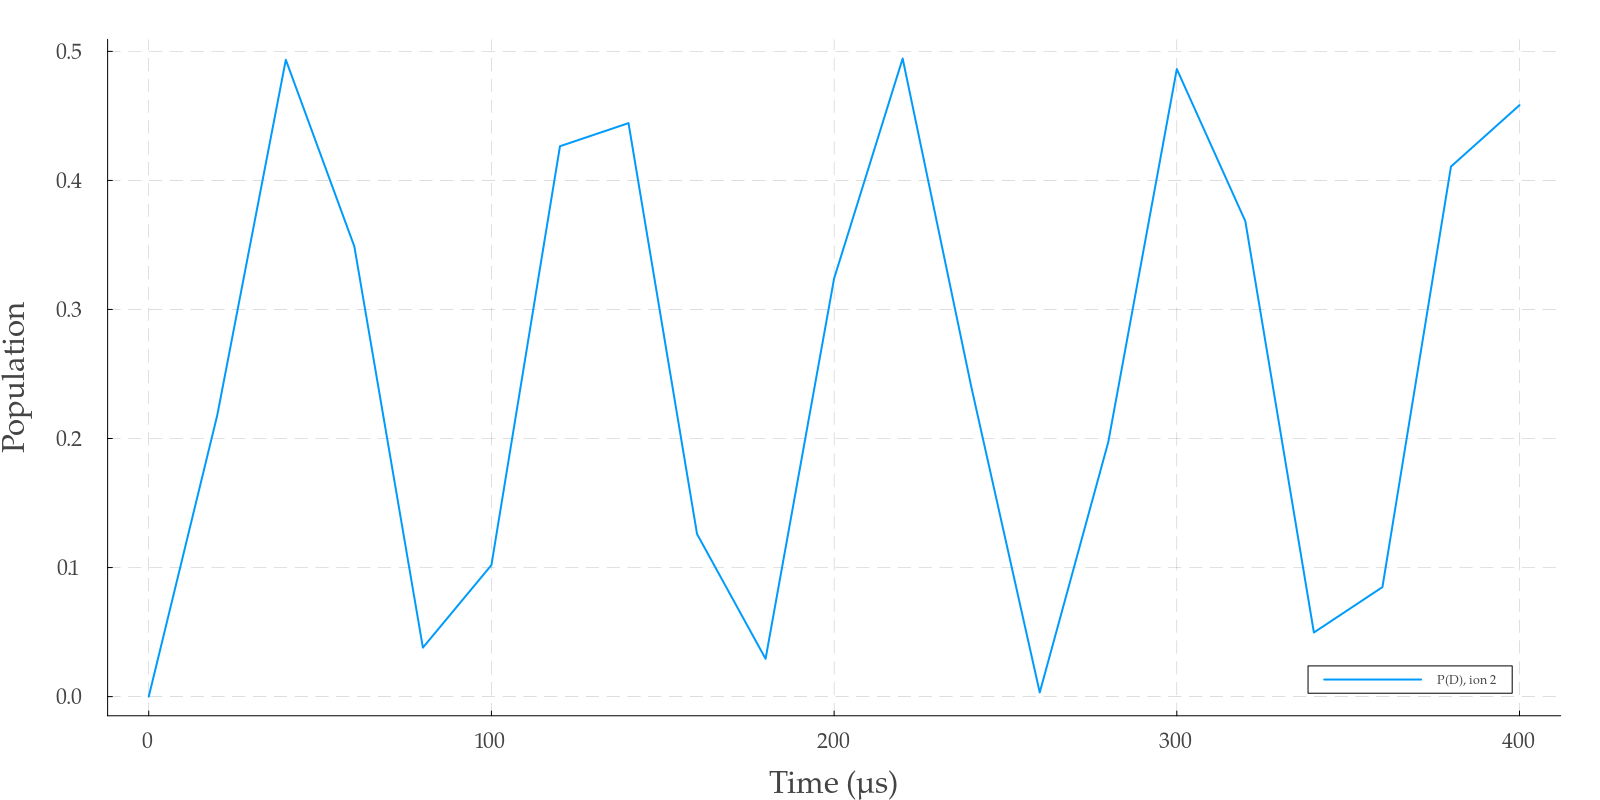

In [63]:
plt.plot(tout_deg2, P_D_deg2, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

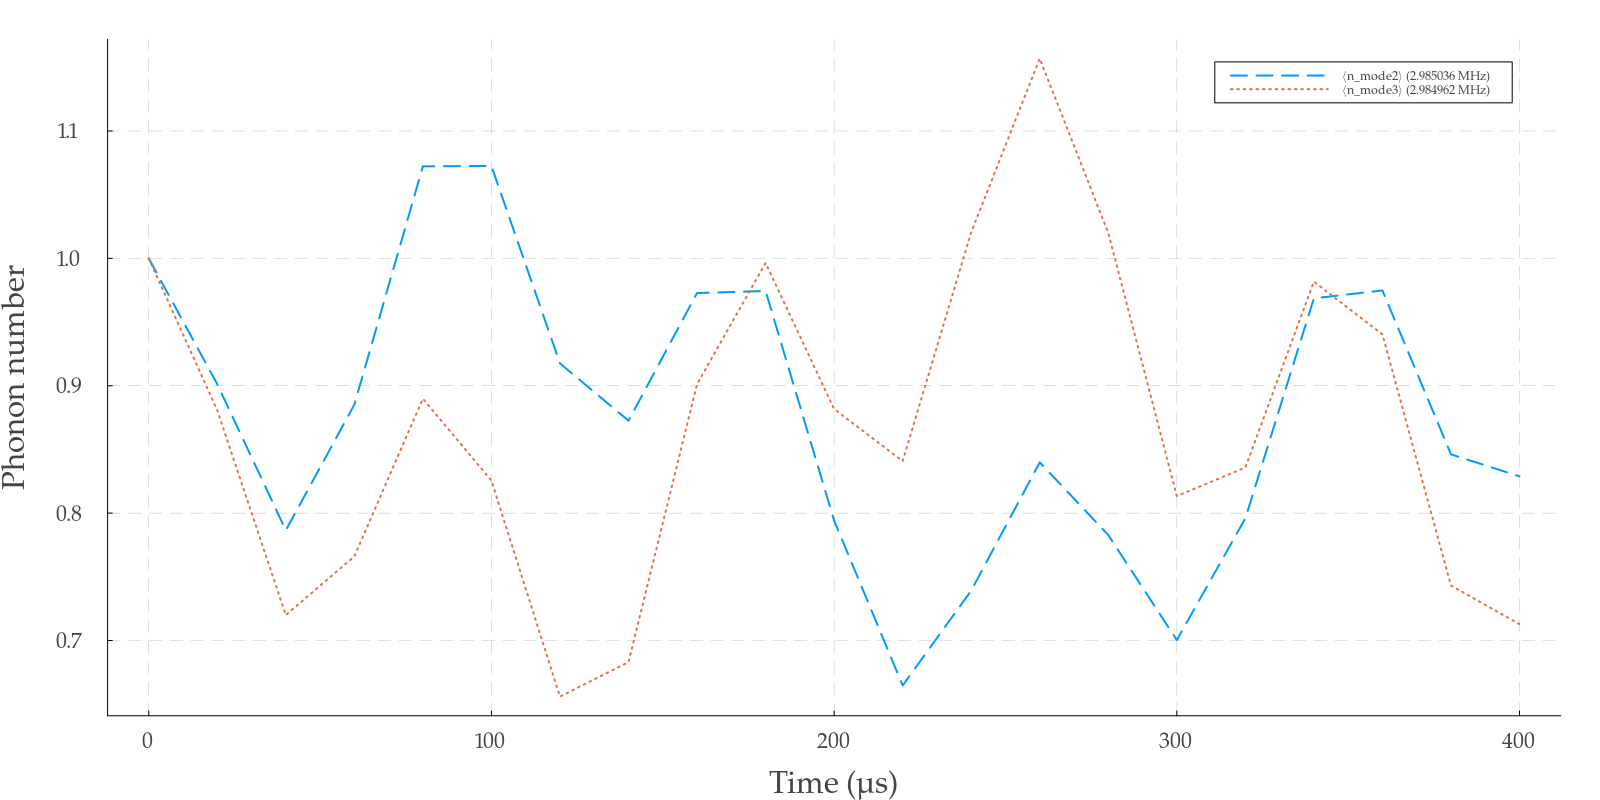

In [64]:
plt.plot(tout_deg2, n_mode2_deg2, ls="dashed", label="⟨n_mode2⟩ (2.985036 MHz)")
plt.plot(tout_deg2, n_mode3_deg2, ls="dotted", label="⟨n_mode3⟩ (2.984962 MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()

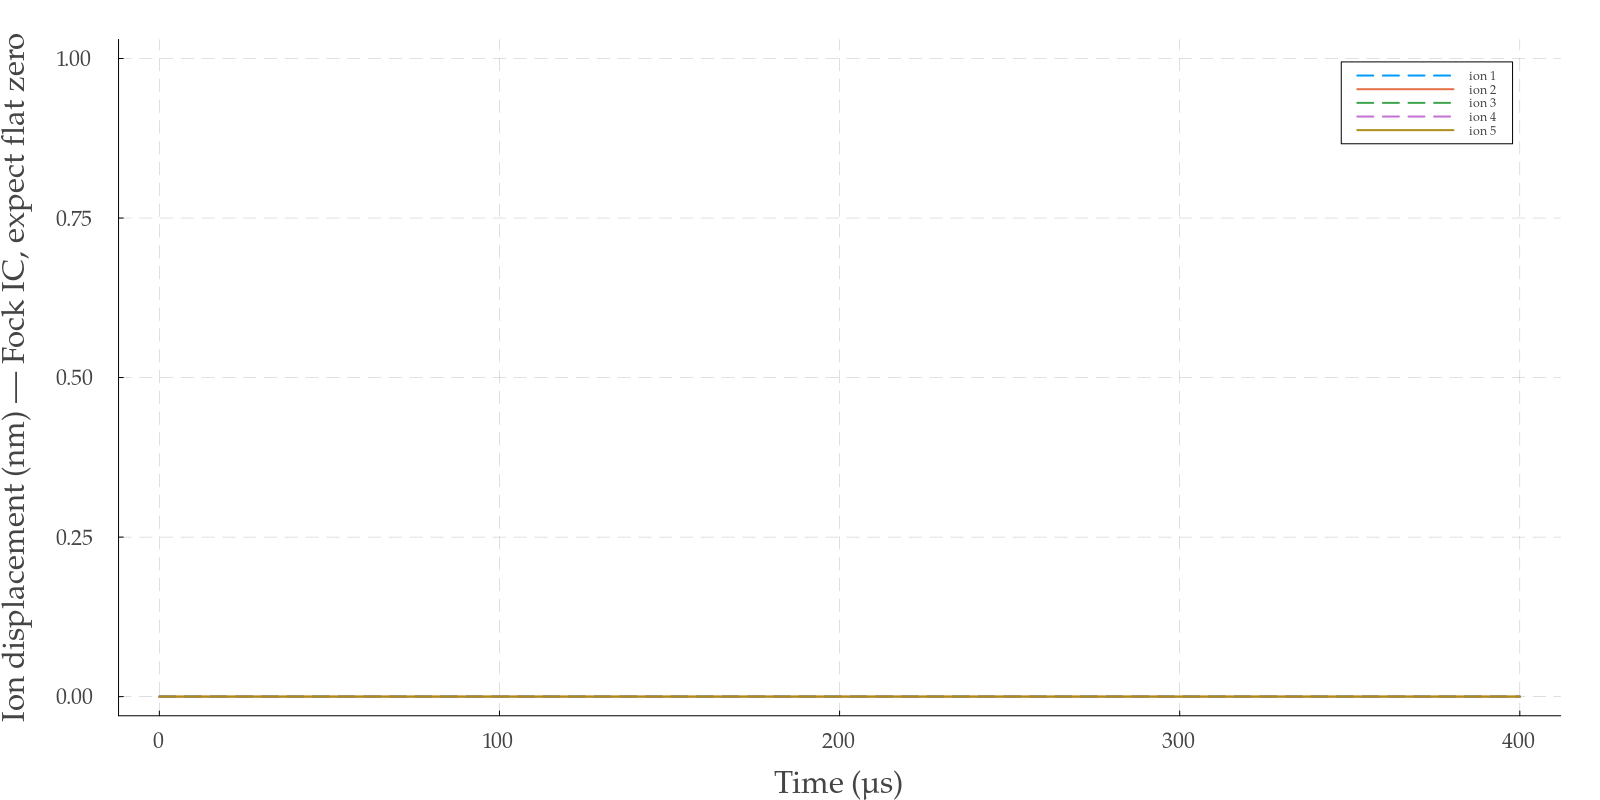

In [65]:
# Reconstruct each ion's physical displacement x_i(t) [nm] in the trap from
# the mode 2/3 quadratures — all other modes were pinned at N=0 (no phonons),
# so they contribute nothing here:
#     x_i(t) = b_i^(2)·x0_2·⟨a_2+a_2†⟩(t) + b_i^(3)·x0_3·⟨a_3+a_3†⟩(t)
# b_i^(k) is ion i's component of mode k's eigenvector (mode_vecs_deg), and
# x0_k = √(ħ/(2 m ω_k)) is that mode's zero-point spread.
#
# NOTE: applied to q_mode2_deg2/q_mode3_deg2 (the Fock-state |1,1⟩ run above),
# this is identically zero at every timestep — not a bug. ⟨a+a†⟩ vanishes for
# any state diagonal in the Fock basis, and the ion-flip-tagged sideband
# process here keeps the reduced motional state exactly diagonal (the ion's
# S/D label is a which-path marker that kills Fock coherence once you trace
# it out). The phonon-NUMBER plot two cells up is the real signature of
# motion for that run. For an actual nonzero x_i(t), see the coherent-state
# rerun two cells below (f21d902b/a7ea7d75), which has genuine Fock coherence.
ħ_deg = IonSim.PhysicalConstants.ħ
m_deg = mass(ions_deg[1])  # same species for all 5 ions

x0_mode2 = √(ħ_deg / (2 * m_deg * 2π * frequency(mode2_deg)))
x0_mode3 = √(ħ_deg / (2 * m_deg * 2π * frequency(mode3_deg)))

x_ions_deg2 = [
    (mode_vecs_deg[2][i] .* x0_mode2 .* q_mode2_deg2 .+ mode_vecs_deg[3][i] .* x0_mode3 .* q_mode3_deg2) .* 1e9  # m -> nm
    for i in 1:5
]

for i in 1:5
    plt.plot(tout_deg2, x_ions_deg2[i], ls=(i == 2 || i == 5 ? "-" : "dashed"), label="ion $i")
end
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Ion displacement (nm) — Fock IC, expect flat zero")
plt.show()

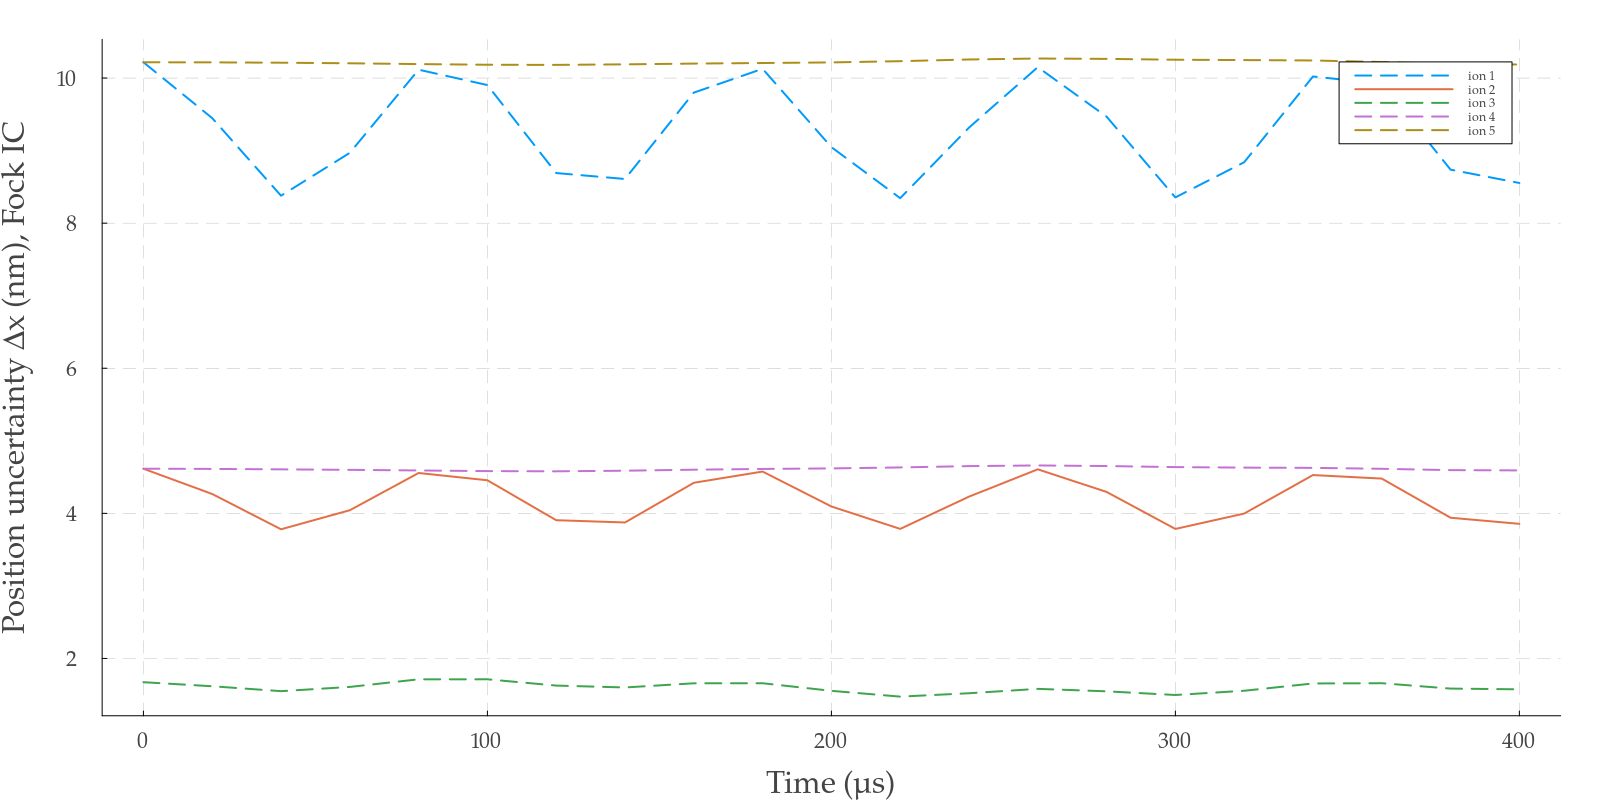

In [66]:
# You might reasonably expect cooling/phonon exchange to change the ion's
# motion — and it does, just not the MEAN position ⟨x⟩ (shown to be exactly
# zero above). What changes is the ion's POSITION UNCERTAINTY: Var(x)
# depends on ⟨q²⟩, not ⟨q⟩, and for any state diagonal in the Fock basis
# Var(q_k) = ⟨q_k²⟩ = 2⟨n_k⟩+1 exactly. So as phonons swap between mode 2
# and mode 3 (see n_mode2_deg2/n_mode3_deg2 above), each ion's positional
# "blob" genuinely swells and shrinks in step. There's also a real
# mode2↔mode3 cross-correlation ⟨q2·q3⟩ that survives tracing out the ion
# (a coherence between the two near-degenerate modes, even though each
# mode's own marginal stays exactly diagonal) — included below.
q2sq_op = q2_op_deg * q2_op_deg
q3sq_op = q3_op_deg * q3_op_deg
q2q3_op = q2_op_deg * q3_op_deg

fout_var_deg2(t, ψ) = (
    real(expect(q2sq_op, ψ)),
    real(expect(q3sq_op, ψ)),
    real(expect(q2q3_op, ψ)),
)

_, sol_var_deg2 = timeevolution.schroedinger_dynamic(tspan_deg2, ρ₀_deg2, h_deg2, fout=fout_var_deg2)
q2sq_deg2 = [s[1] for s in sol_var_deg2]
q3sq_deg2 = [s[2] for s in sol_var_deg2]
q2q3_deg2 = [s[3] for s in sol_var_deg2]

# Δx_i(t) = √Var(x_i)(t), with
# Var(x_i) = (b_i^(2) x0_2)² Var(q2) + (b_i^(3) x0_3)² Var(q3)
#            + 2 (b_i^(2) x0_2)(b_i^(3) x0_3) Cov(q2,q3)
# using ⟨q2⟩=⟨q3⟩=0 exactly, so Var(q_k)=⟨q_k²⟩ and Cov(q2,q3)=⟨q2 q3⟩ directly.
dx_ions_deg2 = [
    sqrt.(
        (mode_vecs_deg[2][i] * x0_mode2)^2 .* q2sq_deg2 .+
        (mode_vecs_deg[3][i] * x0_mode3)^2 .* q3sq_deg2 .+
        2 * (mode_vecs_deg[2][i] * x0_mode2) * (mode_vecs_deg[3][i] * x0_mode3) .* q2q3_deg2
    ) .* 1e9  # m -> nm
    for i in 1:5
]

for i in 1:5
    plt.plot(tout_deg2, dx_ions_deg2[i], ls=(i == 2 ? "-" : "dashed"), label="ion $i")
end
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Position uncertainty Δx (nm), Fock IC")
plt.show()

In [67]:
# Re-run the ion2/ion5 addressing scenario, but start modes 2 and 3 in
# COHERENT states instead of Fock states |1⟩. Fock states give ⟨a+a†⟩=0
# identically — the ion's S/D state tags which phonon-number branch you're
# in, so tracing out the ion kills any Fock coherence in the reduced motional
# state (see explanation above the previous, all-zero position plot).
# Coherent states DO carry genuine Fock coherence, so this version shows
# actual semiclassical ion motion instead of a flat zero.
for (i, m) in enumerate(xm_deg2)
    modecutoff!(m, (i == 2 || i == 3) ? 8 : 0)  # headroom above |α|=1
end
h_coh_deg2 = hamiltonian(chamber_deg2, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)

α2, α3 = 1.0 + 0im, 1.0 + 0im  # motional coherent-state amplitudes, modes 2 & 3

ρ₀_coh_deg2 = tensor([dm(ions_deg[i]["S"]) for i in 1:5]...)
mode_states_coh_deg2 = [
    i == 2 ? dm(IonSim.coherentstate(mode2_deg, α2)) :
    i == 3 ? dm(IonSim.coherentstate(mode3_deg, α3)) :
    dm(fockstate(xm_deg2[i], 0))
    for i in 1:5
]
ρ₀_coh_deg2 = ρ₀_coh_deg2 ⊗ mode_states_coh_deg2[1] ⊗ mode_states_coh_deg2[2] ⊗ mode_states_coh_deg2[3] ⊗ mode_states_coh_deg2[4] ⊗ mode_states_coh_deg2[5]

# rebuild the quadrature operators fresh — the earlier q2_op_deg/q3_op_deg
# were sized for the old modecutoff=3 Hilbert space, now enlarged to 8
q2_op_coh = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ (IonSim.create(mode2_deg) + IonSim.destroy(mode2_deg)) ⊗ one(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
q3_op_coh = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(mode2_deg) ⊗ (IonSim.create(mode3_deg) + IonSim.destroy(mode3_deg)) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])

fout_coh_deg2(t, ψ) = (
    real(expect(q2_op_coh, ψ)),
    real(expect(q3_op_coh, ψ)),
)

tspan_coh_deg2 = 0:5:400
tout_coh_deg2, sol_coh_deg2 = timeevolution.schroedinger_dynamic(tspan_coh_deg2, ρ₀_coh_deg2, h_coh_deg2, fout=fout_coh_deg2)
q_mode2_coh_deg2 = [s[1] for s in sol_coh_deg2]
q_mode3_coh_deg2 = [s[2] for s in sol_coh_deg2]

81-element Vector{Float64}:
 1.9999772512245182
 1.99924875964351
 1.9970752349175043
 1.993492416665645
 1.9885588386599502
 1.9823553163881458
 1.9749833313165397
 1.9665631555057184
 1.9572312530492444
 1.9471391784395042
 1.936450062624141
 1.9253375065059641
 1.9139796377820002
 ⋮
 1.8301127854058137
 1.8236281312961442
 1.8183930724655941
 1.8144869697104042
 1.8119665880199916
 1.8108681524302639
 1.811206173242011
 1.8129728435599064
 1.8161365195621093
 1.8206410345835664
 1.8264068743609925
 1.8333327564505957

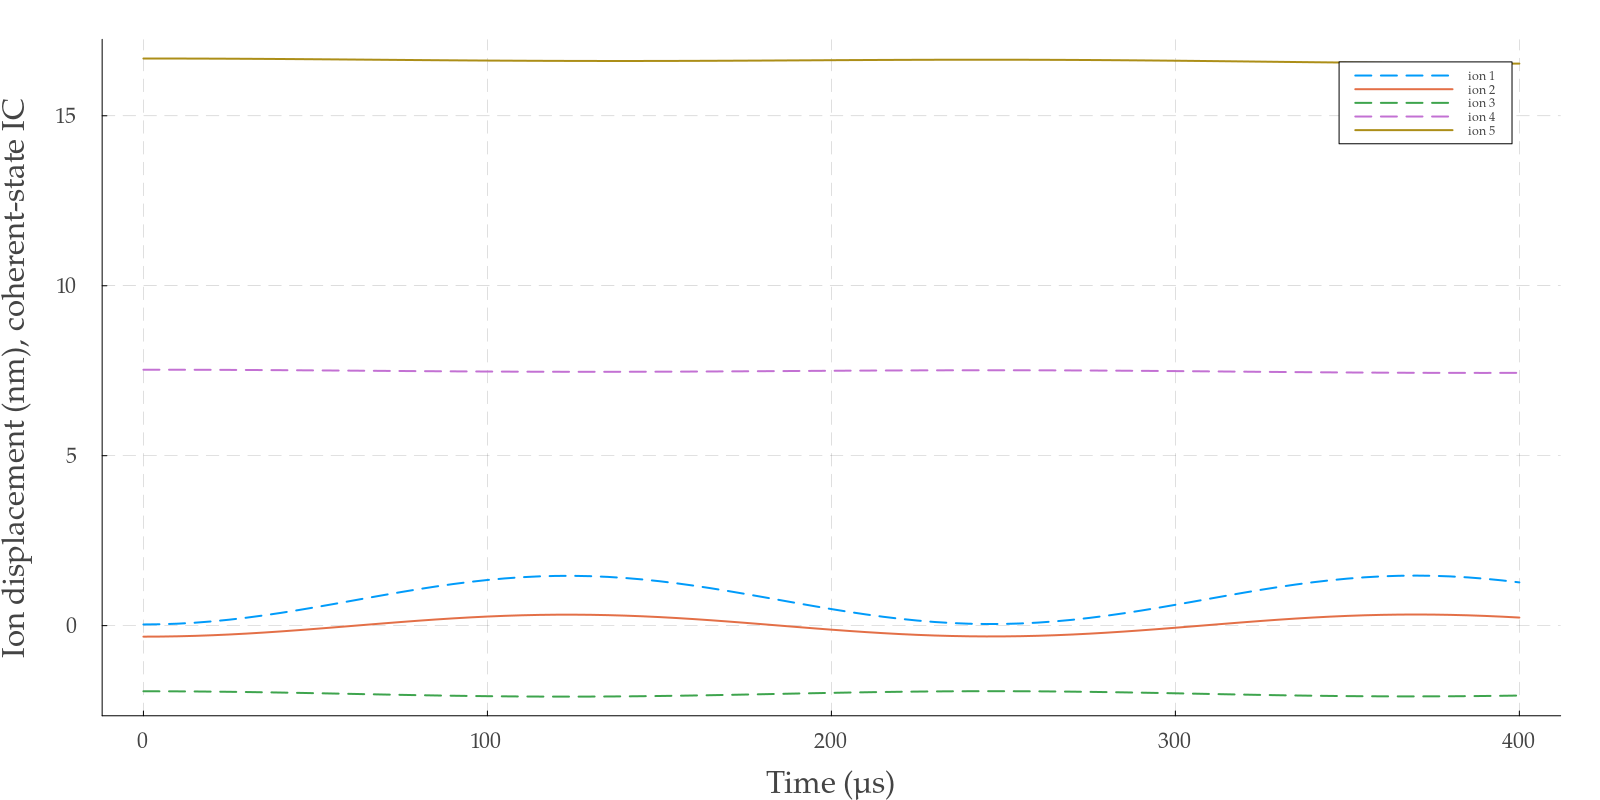

In [68]:
# Same reconstruction formula as before (x0_mode2/x0_mode3 don't depend on
# modecutoff, so they're still valid), applied to the coherent-state run.
x_ions_coh_deg2 = [
    (mode_vecs_deg[2][i] .* x0_mode2 .* q_mode2_coh_deg2 .+ mode_vecs_deg[3][i] .* x0_mode3 .* q_mode3_coh_deg2) .* 1e9  # m -> nm
    for i in 1:5
]

for i in 1:5
    plt.plot(tout_coh_deg2, x_ions_coh_deg2[i], ls=(i == 2 || i == 5 ? "-" : "dashed"), label="ion $i")
end
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Ion displacement (nm), coherent-state IC")
plt.show()

In [69]:
# Same idea, but for mode 4 and mode 5 (2.936844 MHz vs 2.934913 MHz — a
# ~1.9 kHz gap, wider than the mode2/mode3 pair but still tiny compared to
# the sideband coupling strength). Reuses the ion-2 chamber/laser built above.
mode4_deg, mode5_deg = xm_deg2[4], xm_deg2[5]
println("η(ion 2, mode 4) = ", lambdicke(mode4_deg, ions_deg[2], laser_deg2))
println("η(ion 2, mode 5) = ", lambdicke(mode5_deg, ions_deg[2], laser_deg2))

for (i, m) in enumerate(xm_deg2)
    modecutoff!(m, (i == 4 || i == 5) ? 3 : 0)
end

Δ_mid_deg45 = -(frequency(mode4_deg) + frequency(mode5_deg)) / 2
detuning!(laser_deg2, Δ_mid_deg45)
h_deg45 = hamiltonian(chamber_deg2, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)

ρ₀_deg45 = tensor([dm(ions_deg[i]["S"]) for i in 1:5]...)
mode_states_deg45 = [dm(fockstate(xm_deg2[i], (i == 4 || i == 5) ? 1 : 0)) for i in 1:5]
ρ₀_deg45 = ρ₀_deg45 ⊗ mode_states_deg45[1] ⊗ mode_states_deg45[2] ⊗ mode_states_deg45[3] ⊗ mode_states_deg45[4] ⊗ mode_states_deg45[5]

n4_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(xm_deg2[2]) ⊗ one(xm_deg2[3]) ⊗ IonSim.number(mode4_deg) ⊗ one(mode5_deg)
n5_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(xm_deg2[2]) ⊗ one(xm_deg2[3]) ⊗ one(mode4_deg) ⊗ IonSim.number(mode5_deg)
PD_op_deg45 = ionprojector(chamber_deg2, "S", "D", "S", "S", "S")

fout_deg45(t, ψ) = (
    real(expect(PD_op_deg45, ψ)),
    real(expect(n4_op_deg, ψ)),
    real(expect(n5_op_deg, ψ)),
)

tspan_deg45 = 0:20:400
tout_deg45, sol_deg45 = timeevolution.schroedinger_dynamic(tspan_deg45, ρ₀_deg45, h_deg45, fout=fout_deg45)
P_D_deg45 = [s[1] for s in sol_deg45]
n_mode4_deg45 = [s[2] for s in sol_deg45]
n_mode5_deg45 = [s[3] for s in sol_deg45]

η(ion 2, mode 4) = 0.025571376903958703
η(ion 2, mode 5) = 0.025202554672767233


21-element Vector{Float64}:
 1.0
 0.7565933207005655
 1.0132937506147435
 0.7313524370703095
 0.9264115488854859
 0.8331054653669526
 0.9133484036815831
 0.8890639905590058
 0.8301791009157967
 0.8653640063709787
 0.9009597640907021
 0.8721050409317527
 0.8789558444026031
 0.8856992443126028
 0.8801905879940417
 0.8096372612494729
 0.8551074287212924
 0.8898378693924842
 0.8768282147832612
 0.9495845911424301
 0.7323236724194226

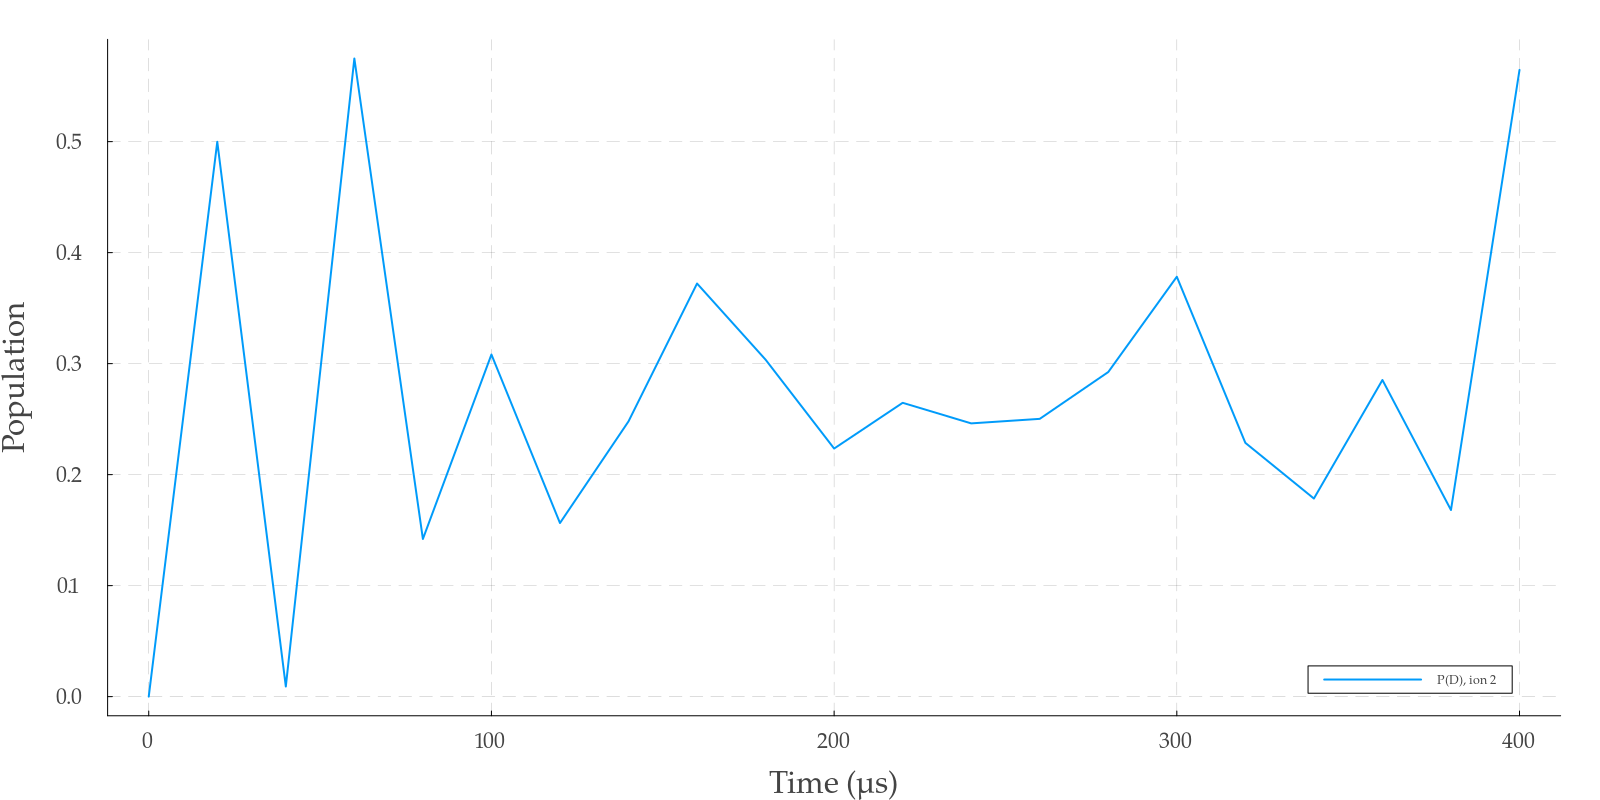

In [70]:
plt.plot(tout_deg45, P_D_deg45, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

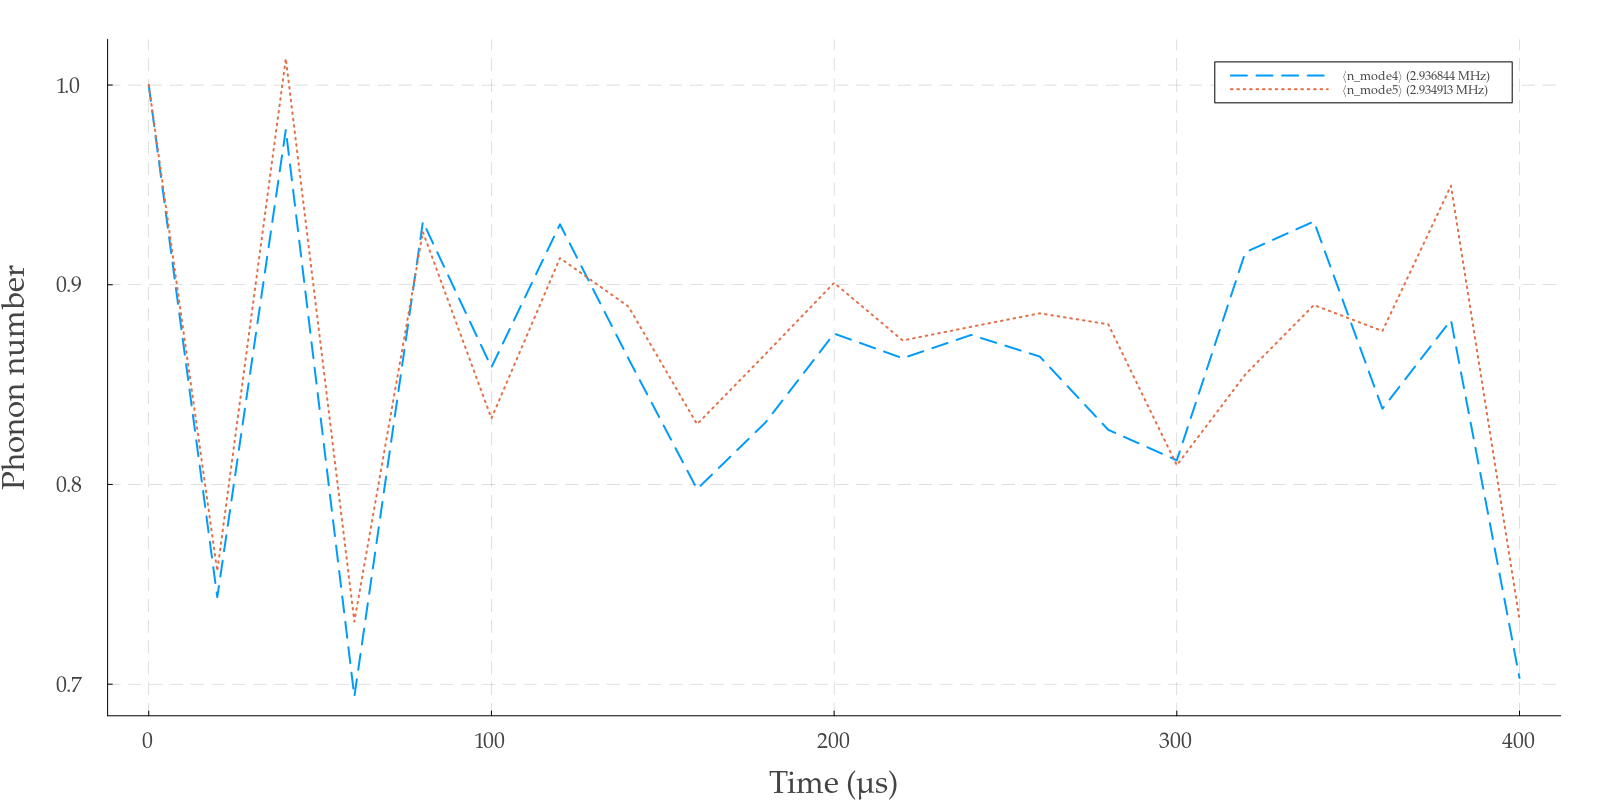

In [71]:
plt.plot(tout_deg45, n_mode4_deg45, ls="dashed", label="⟨n_mode4⟩ (2.936844 MHz)")
plt.plot(tout_deg45, n_mode5_deg45, ls="dotted", label="⟨n_mode5⟩ (2.934913 MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()

In [72]:
# Pipeline step 2 of 2, as a reusable function: given a chosen ion to
# address, build a fresh chain/chamber/laser for the given mode structure,
# find that ion's TWO most strongly coupled modes (mirroring the mode2/mode3
# and mode4/mode5 crosstalk examples earlier in this notebook), drive one of
# two possible detunings, and return timeseries for P(D) and both modes'
# phonon numbers.
#
# detuning_mode = :mid (default): Δ = -(freqA+freqB)/2, halfway between the
#     two red sidebands -- single-phonon exchange between mode A and mode B,
#     lamb_dicke_order=1 (same as the mode2/mode3 cells above).
# detuning_mode = :sum: Δ = -(freqA+freqB), the JOINT red sideband -- removes
#     one phonon from BOTH modes at once while exciting the ion
#     (|1,1⟩ -> |0,0⟩). This is a second-order process, so it needs
#     lamb_dicke_order=2 -- the order-1 Hamiltonian doesn't contain this
#     coupling term at all (same as the earlier Δ=-(νᵣ+νₐ) joint-sideband cell).
#
# Two methods:
#   run_tweezer_pipeline(ion, N, mode_freqs, mode_vecs, tweezed_ions; tspan, verbose, detuning_mode)
#       -- the actual simulation, parameterized so it can be reused for any
#          single mode structure (e.g. inside a power sweep).
#   run_tweezer_pipeline(ion; tspan, verbose, detuning_mode)
#       -- convenience wrapper for the single config exported to
#          tweezer_config.jl (what the ion-1/ion-2 cells below call).
include("tweezer_config.jl")
@assert N_pipeline <= 10 "N_pipeline=$N_pipeline: the 2^N ion Hilbert space is likely intractable here -- export a smaller N."

function run_tweezer_pipeline(addressed_ion, N, mode_freqs, mode_vecs, tweezed_ions; tspan=0:20:400, verbose=true, detuning_mode=:mid)
    ions_pipeline = [Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")]) for _ in 1:N]
    custom_modes_pipeline = [
        VibrationalMode(f, v, axis=x̂, N=0) for (f, v) in zip(mode_freqs, mode_vecs)
    ]
    vm_pipeline = (x=custom_modes_pipeline, y=VibrationalMode[], z=VibrationalMode[])
    ionpositions_pipeline = linear_equilibrium_positions(N) .* 5e-6

    chain_pipeline = LinearChain(ions_pipeline, vm_pipeline, ionpositions_pipeline)
    laser_pipeline = Laser()
    chamber_pipeline = Chamber(iontrap=chain_pipeline, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_pipeline])

    wavelength_from_transition!(laser_pipeline, ions_pipeline[addressed_ion], ("S", "D"), chamber_pipeline)
    polarization!(laser_pipeline, ẑ)
    wavevector!(laser_pipeline, (x̂ + ẑ)/√2)
    pointing!(laser_pipeline, [(addressed_ion, 1.0)])
    intensity_from_rabifrequency!(1, 5e5, addressed_ion, ("S", "D"), chamber_pipeline)

    # find this ion's two most strongly coupled modes
    xm_pipeline = xmodes(chamber_pipeline)
    etas_pipeline = [lambdicke(mo, ions_pipeline[addressed_ion], laser_pipeline) for mo in xm_pipeline]
    top2 = sort(sortperm(abs.(etas_pipeline), rev=true)[1:2])
    modeA_idx, modeB_idx = top2[1], top2[2]
    modeA, modeB = xm_pipeline[modeA_idx], xm_pipeline[modeB_idx]
    role = addressed_ion in tweezed_ions ? "tweezed" : "spectator"

    if verbose
        println("addressing ion ", addressed_ion, " (", role, ")")
        for (i, η) in enumerate(etas_pipeline)
            tag = (i == modeA_idx || i == modeB_idx) ? "  <- driven" : ""
            println("  mode ", i, "  freq=", round(mode_freqs[i] / 1e6, digits=6), " MHz  η=", η, tag)
        end
    end

    for (i, mo) in enumerate(xm_pipeline)
        modecutoff!(mo, (i == modeA_idx || i == modeB_idx) ? 3 : 0)
    end

    if detuning_mode == :mid
        Δ = -(frequency(modeA) + frequency(modeB)) / 2
        lamb_dicke_order_pipeline = 1
    elseif detuning_mode == :sum
        Δ = -(frequency(modeA) + frequency(modeB))
        lamb_dicke_order_pipeline = 2
    else
        error("detuning_mode must be :mid or :sum, got $detuning_mode")
    end
    detuning!(laser_pipeline, Δ)

    h_pipeline = hamiltonian(chamber_pipeline, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=lamb_dicke_order_pipeline)

    ρ₀_pipeline = tensor([dm(ions_pipeline[i]["S"]) for i in 1:N]...)
    mode_states_pipeline = [dm(fockstate(xm_pipeline[i], (i == modeA_idx || i == modeB_idx) ? 1 : 0)) for i in 1:N]
    ρ₀_pipeline = ρ₀_pipeline ⊗ reduce(⊗, mode_states_pipeline)

    ion_labels_pipeline = fill("S", N)
    ion_labels_pipeline[addressed_ion] = "D"
    PD_op_pipeline = ionprojector(chamber_pipeline, ion_labels_pipeline...)
    nA_op_pipeline = tensor([one(ions_pipeline[i]) for i in 1:N]...) ⊗
        reduce(⊗, [i == modeA_idx ? IonSim.number(xm_pipeline[i]) : one(xm_pipeline[i]) for i in 1:N])
    nB_op_pipeline = tensor([one(ions_pipeline[i]) for i in 1:N]...) ⊗
        reduce(⊗, [i == modeB_idx ? IonSim.number(xm_pipeline[i]) : one(xm_pipeline[i]) for i in 1:N])

    fout_pipeline(t, ψ) = (
        real(expect(PD_op_pipeline, ψ)),
        real(expect(nA_op_pipeline, ψ)),
        real(expect(nB_op_pipeline, ψ)),
    )

    tout_pipeline, sol_pipeline = timeevolution.schroedinger_dynamic(tspan, ρ₀_pipeline, h_pipeline, fout=fout_pipeline)
    P_D_pipeline = [s[1] for s in sol_pipeline]
    n_A_pipeline = [s[2] for s in sol_pipeline]
    n_B_pipeline = [s[3] for s in sol_pipeline]

    return (
        tout=tout_pipeline, P_D=P_D_pipeline,
        n_A=n_A_pipeline, n_B=n_B_pipeline,
        modeA_idx=modeA_idx, modeB_idx=modeB_idx,
        freqA=frequency(modeA), freqB=frequency(modeB),
        etas=etas_pipeline, role=role,
    )
end

run_tweezer_pipeline(addressed_ion; tspan=0:20:400, verbose=true, detuning_mode=:mid) =
    run_tweezer_pipeline(addressed_ion, N_pipeline, mode_freqs_pipeline, mode_vecs_pipeline, tweezed_ions_pipeline; tspan=tspan, verbose=verbose, detuning_mode=detuning_mode)

run_tweezer_pipeline (generic function with 2 methods)

addressing ion 1 (spectator)
  mode 1  freq=3.007987 MHz  η=0.013378643114743249
  mode 2  freq=2.984962 MHz  η=-0.025364431139081864  <- driven
  mode 3  freq=2.97128 MHz  η=-0.02383315562789316  <- driven
  mode 4  freq=2.936844 MHz  η=-0.012061626736614713
  mode 5  freq=2.917319 MHz  η=0.006453802927087206


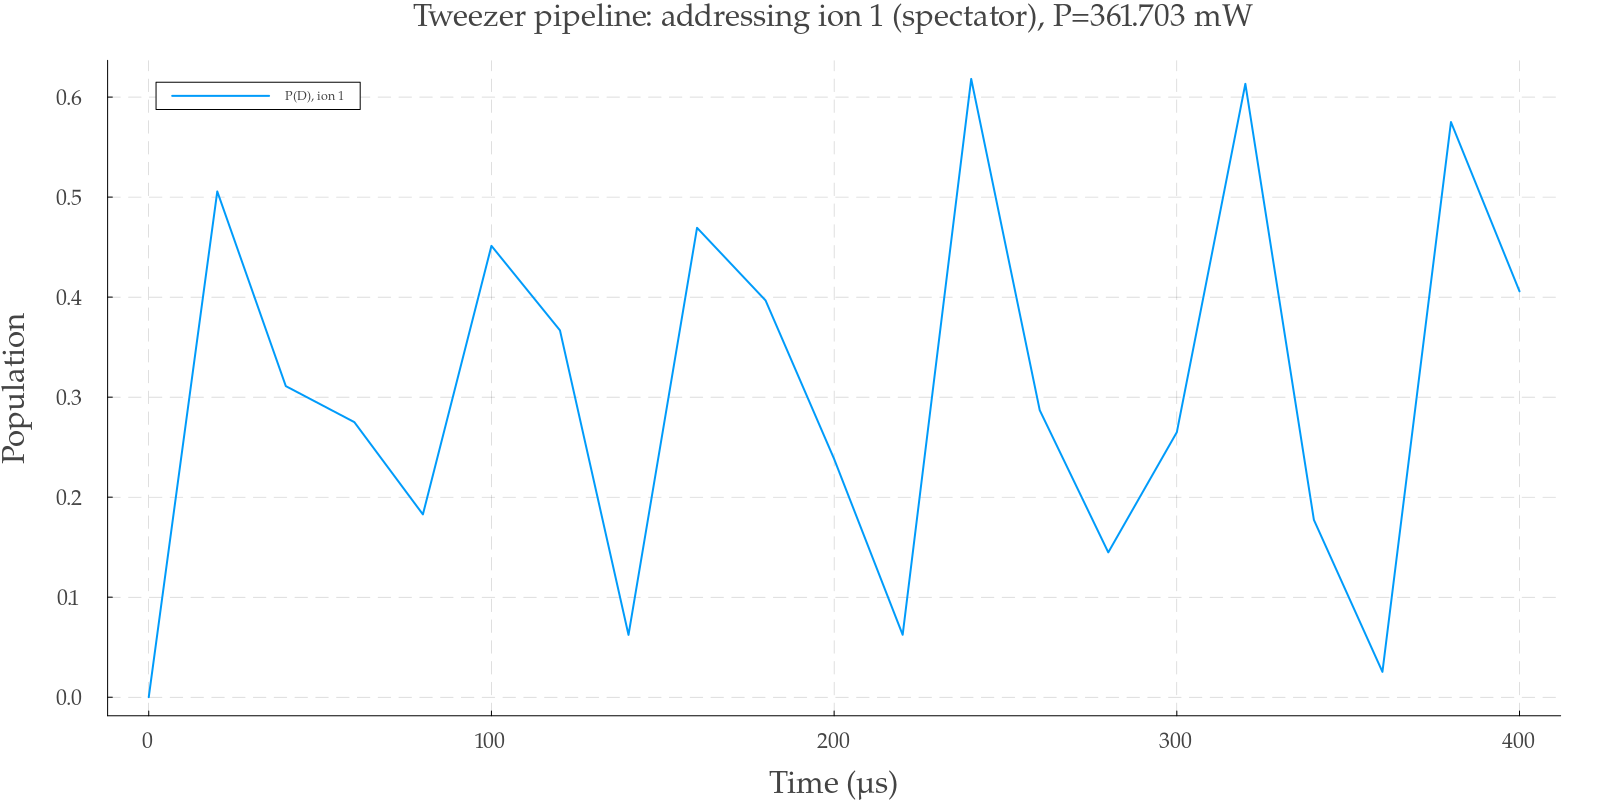

In [73]:
result_ion1_pipeline = run_tweezer_pipeline(1)
plt.plot(result_ion1_pipeline.tout, result_ion1_pipeline.P_D, label="P(D), ion 1")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
Plots.title!("Tweezer pipeline: addressing ion 1 ($(result_ion1_pipeline.role)), P=$(round(P_pipeline*1e3, digits=3)) mW")
plt.show()

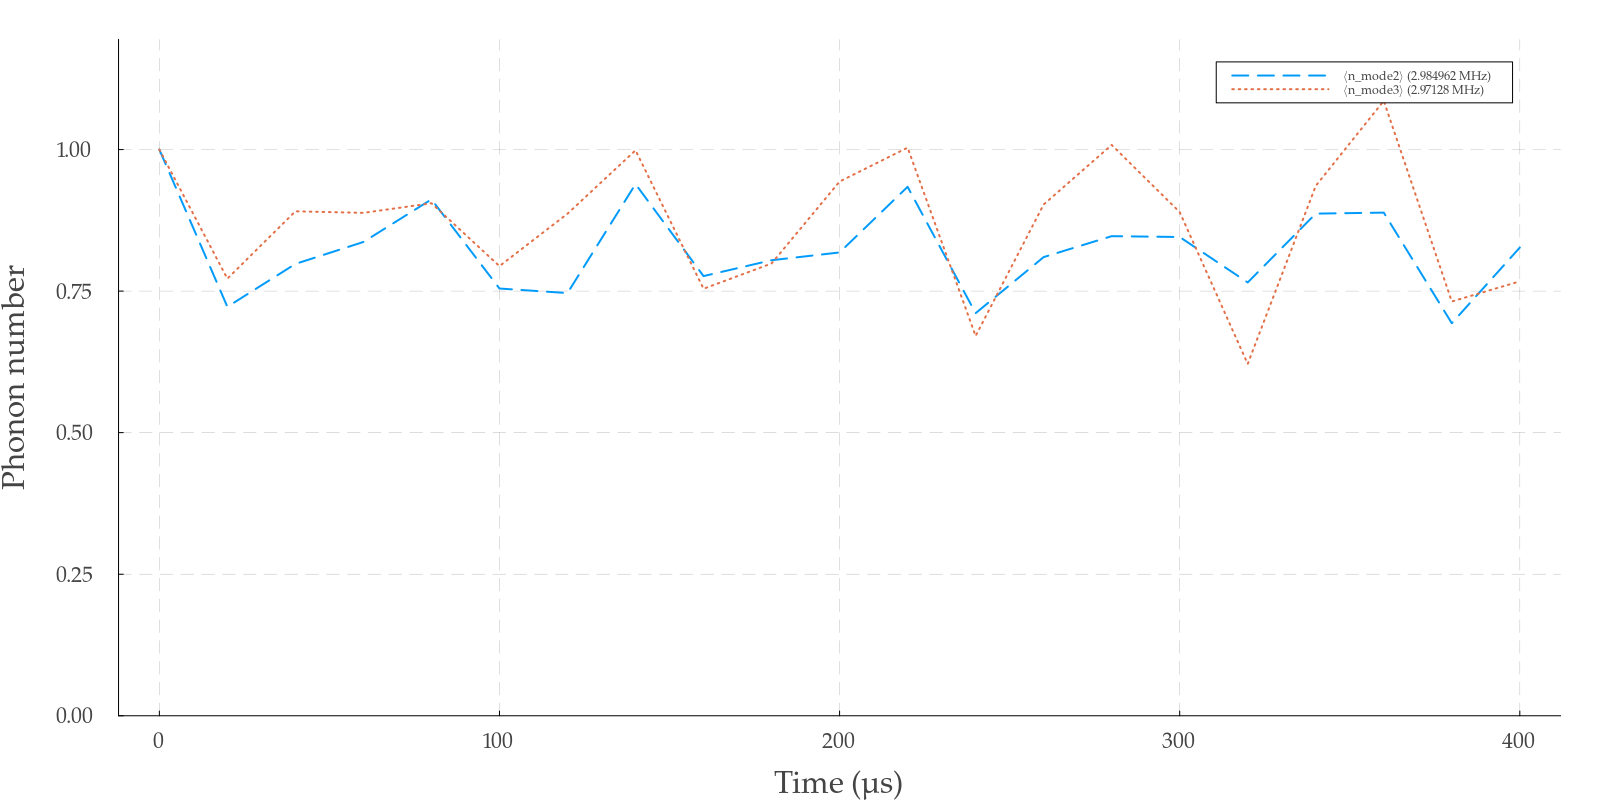

In [74]:
plt.plot(result_ion1_pipeline.tout, result_ion1_pipeline.n_A, ls="dashed",
    label="⟨n_mode$(result_ion1_pipeline.modeA_idx)⟩ ($(round(result_ion1_pipeline.freqA/1e6, digits=6)) MHz)")
plt.plot(result_ion1_pipeline.tout, result_ion1_pipeline.n_B, ls="dotted",
    label="⟨n_mode$(result_ion1_pipeline.modeB_idx)⟩ ($(round(result_ion1_pipeline.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.ylim(0, max(maximum(result_ion1_pipeline.n_A), maximum(result_ion1_pipeline.n_B)) * 1.1)
plt.show()

addressing ion 2 (spectator)
  mode 1  freq=3.007987 MHz  η=0.017078404321509363
  mode 2  freq=2.984962 MHz  η=-0.011964013733132915
  mode 3  freq=2.97128 MHz  η=0.0038254604158654347
  mode 4  freq=2.936844 MHz  η=0.025571376597239407  <- driven
  mode 5  freq=2.917319 MHz  η=-0.022115300990772326  <- driven


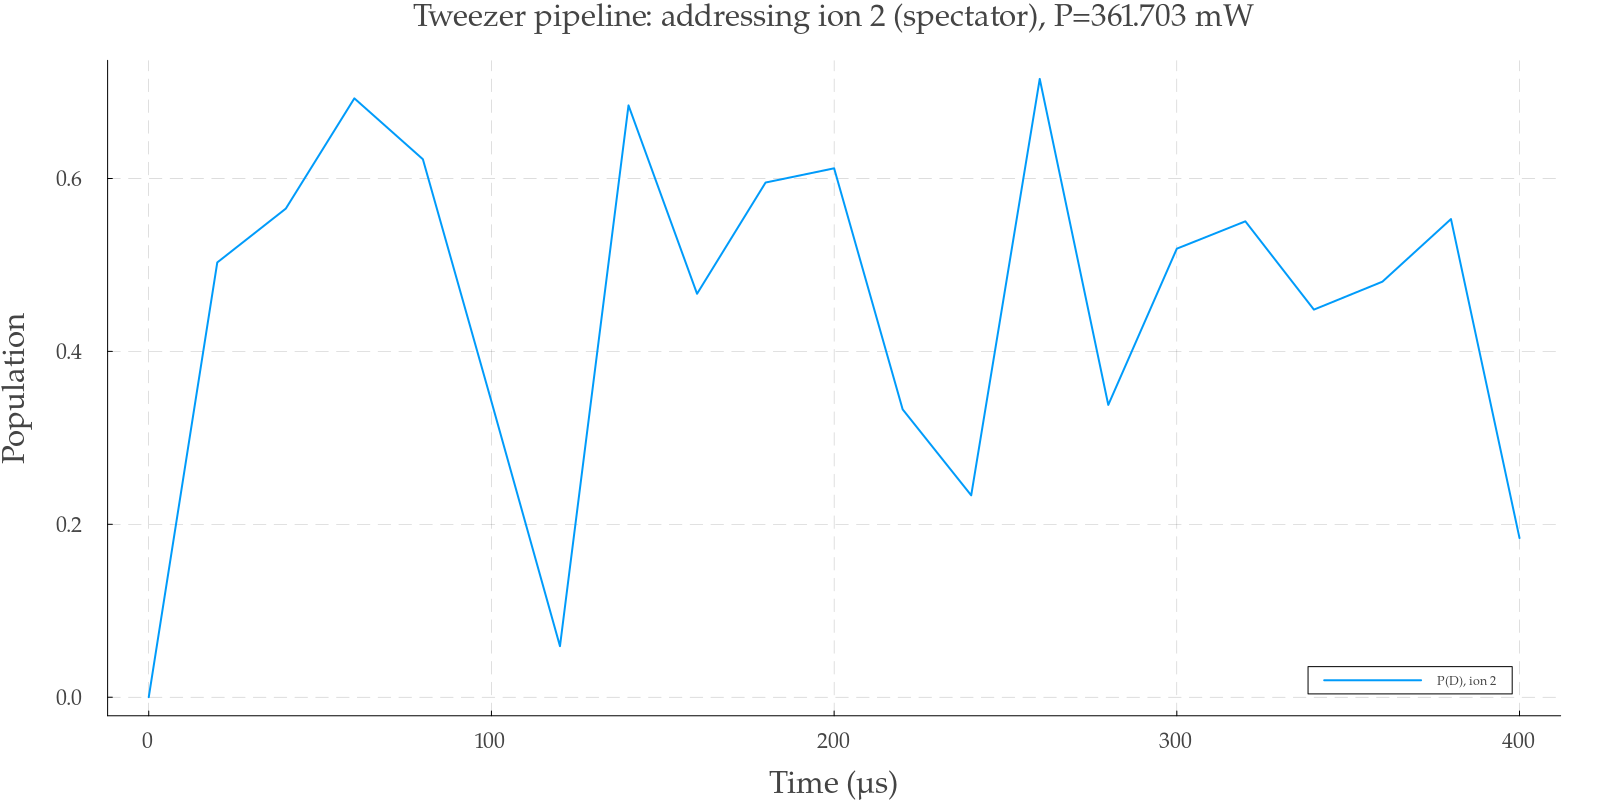

In [75]:
result_ion2_pipeline = run_tweezer_pipeline(2)
plt.plot(result_ion2_pipeline.tout, result_ion2_pipeline.P_D, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
Plots.title!("Tweezer pipeline: addressing ion 2 ($(result_ion2_pipeline.role)), P=$(round(P_pipeline*1e3, digits=3)) mW")
plt.show()

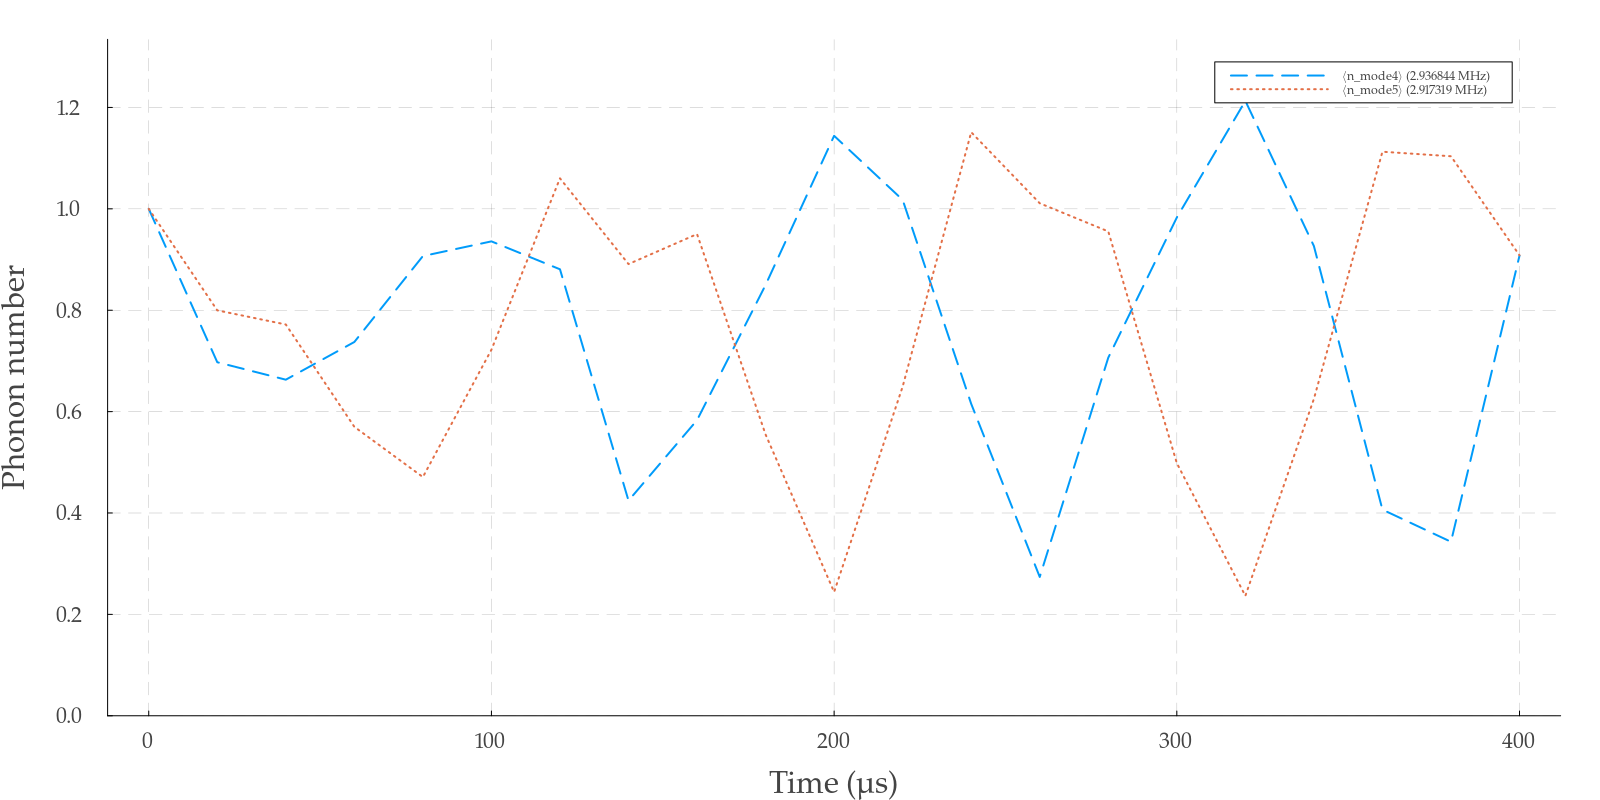

In [76]:
plt.plot(result_ion2_pipeline.tout, result_ion2_pipeline.n_A, ls="dashed",
    label="⟨n_mode$(result_ion2_pipeline.modeA_idx)⟩ ($(round(result_ion2_pipeline.freqA/1e6, digits=6)) MHz)")
plt.plot(result_ion2_pipeline.tout, result_ion2_pipeline.n_B, ls="dotted",
    label="⟨n_mode$(result_ion2_pipeline.modeB_idx)⟩ ($(round(result_ion2_pipeline.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.ylim(0, max(maximum(result_ion2_pipeline.n_A), maximum(result_ion2_pipeline.n_B)) * 1.1)
plt.show()

In [77]:
# Power sweep: for a chosen ion, run run_tweezer_pipeline at EVERY tweezer
# power exported to tweezer_config_sweep.jl (from the sweep cell in
# animation.ipynb), and pick out whichever power drives the phonon-number
# exchange closest to a full swap -- min(⟨n_A⟩, ⟨n_B⟩) closest to 0 -- within
# tspan. If nothing gets close to 0, widen tspan (the exchange may just need
# longer than the default 400 μs window to complete) or widen P_sweep in the
# Python export cell.
# detuning_mode is passed straight through to run_tweezer_pipeline -- :mid
# (default) sweeps the single-phonon exchange scenario, :sum sweeps the
# joint red-sideband scenario (remember :sum needs a much longer tspan to
# show anything, same as the ion-1/ion-2 :sum cells above).
# Each result also carries f_tweezer [Hz] -- the tweezer trap frequency that
# power corresponds to (omega_tweezer_r/(2*pi), computed on the Python side),
# so results can be read against a physical frequency instead of raw power.
include("tweezer_config_sweep.jl")

function sweep_tweezer_pipeline(addressed_ion; tspan=0:20:400, detuning_mode=:mid)
    sweep_results = NamedTuple[]
    for (P, f_tw, freqs, vecs) in zip(P_sweep_pipeline, f_tweezer_sweep_pipeline, mode_freqs_sweep_pipeline, mode_vecs_sweep_pipeline)
        r = run_tweezer_pipeline(addressed_ion, N_pipeline, freqs, vecs, tweezed_ions_pipeline; tspan=tspan, verbose=false, detuning_mode=detuning_mode)
        min_n = min(minimum(r.n_A), minimum(r.n_B))
        push!(sweep_results, (P=P, f_tweezer=f_tw, result=r, min_n=min_n))
    end

    for res in sweep_results
        println("P=", round(res.P * 1e3, digits=3), " mW   f_tweezer=", round(res.f_tweezer / 1e6, digits=4),
                 " MHz   min(⟨n_A⟩,⟨n_B⟩)=", round(res.min_n, digits=4))
    end

    winner = sweep_results[argmin([res.min_n for res in sweep_results])]
    println()
    println("winner: P=", round(winner.P * 1e3, digits=3), " mW   f_tweezer=",
             round(winner.f_tweezer / 1e6, digits=4), " MHz  (min phonon number reached = ",
             round(winner.min_n, digits=4), ")")

    return sweep_results, winner
end

sweep_tweezer_pipeline (generic function with 1 method)

P=50.0 mW   f_tweezer=0.1512 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2885
P=89.474 mW   f_tweezer=0.2023 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2328
P=128.947 mW   f_tweezer=0.2428 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.3109
P=168.421 mW   f_tweezer=0.2775 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2522
P=207.895 mW   f_tweezer=0.3083 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.4129
P=247.368 mW   f_tweezer=0.3363 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.4493
P=286.842 mW   f_tweezer=0.3622 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.6371
P=326.316 mW   f_tweezer=0.3863 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.6148
P=365.789 mW   f_tweezer=0.409 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.6125
P=405.263 mW   f_tweezer=0.4305 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.6059
P=444.737 mW   f_tweezer=0.451 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.575
P=484.211 mW   f_tweezer=0.4706 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5934
P=523.684 mW   f_tweezer=0.4894 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.536
P=563.158 mW   f_tweezer=0.5075 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5574
P=602.632 mW   f_tweezer=0.525 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5902
P=642.105 mW   f_tweezer=0.5419 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.603
P=681.579 mW   f_t

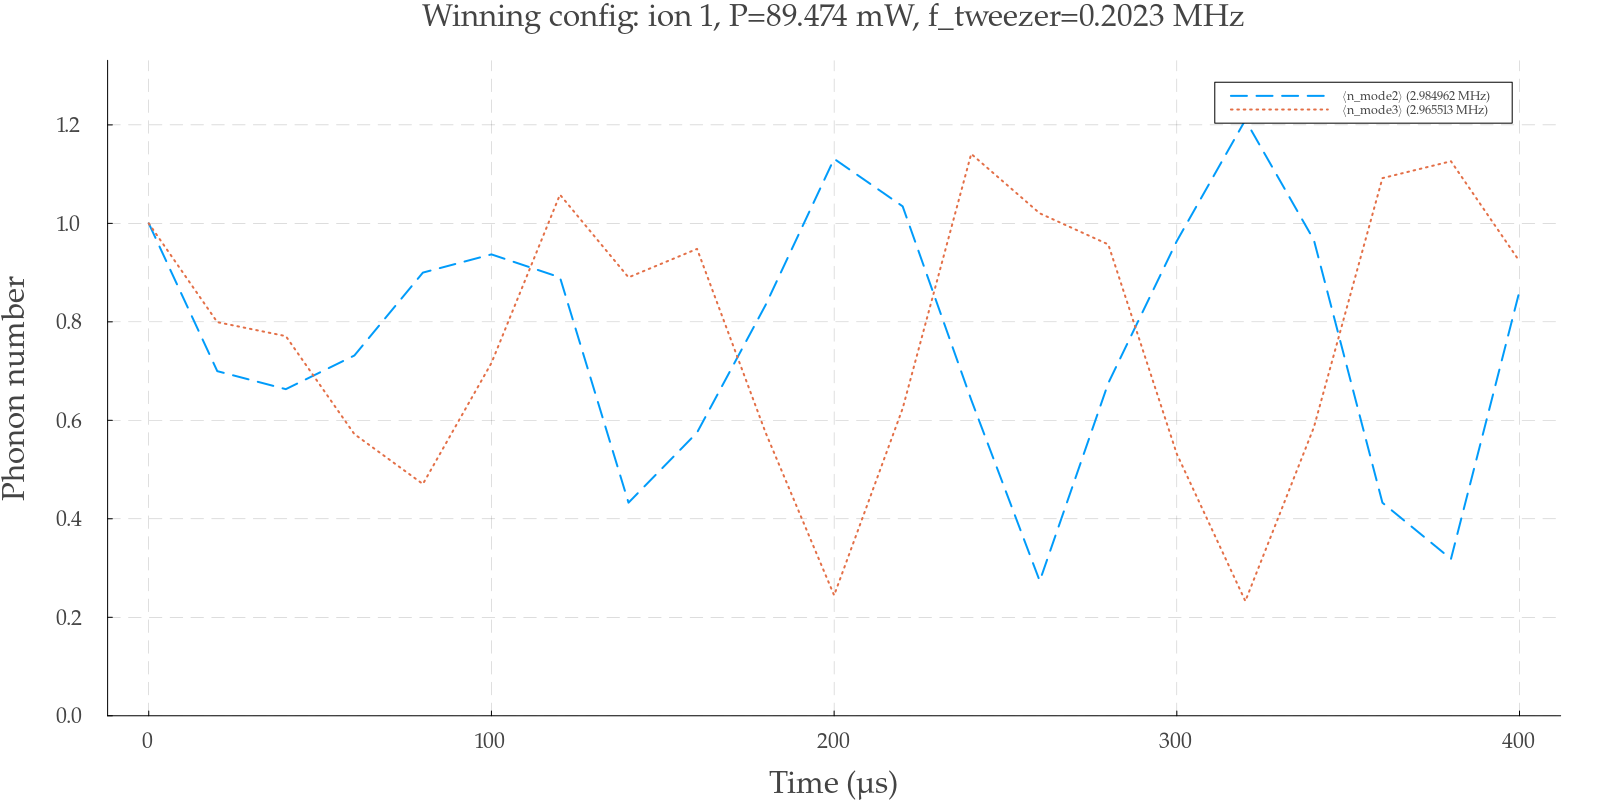

In [78]:
sweep_results_ion1, winner_ion1 = sweep_tweezer_pipeline(1)

plt.plot(winner_ion1.result.tout, winner_ion1.result.n_A, ls="dashed",
    label="⟨n_mode$(winner_ion1.result.modeA_idx)⟩ ($(round(winner_ion1.result.freqA/1e6, digits=6)) MHz)")
plt.plot(winner_ion1.result.tout, winner_ion1.result.n_B, ls="dotted",
    label="⟨n_mode$(winner_ion1.result.modeB_idx)⟩ ($(round(winner_ion1.result.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
Plots.title!("Winning config: ion 1, P=$(round(winner_ion1.P*1e3, digits=3)) mW, f_tweezer=$(round(winner_ion1.f_tweezer/1e6, digits=4)) MHz")
plt.ylim(0, max(maximum(winner_ion1.result.n_A), maximum(winner_ion1.result.n_B)) * 1.1)
plt.show()

P=50.0 mW   f_tweezer=0.1512 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5344
P=89.474 mW   f_tweezer=0.2023 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.466
P=128.947 mW   f_tweezer=0.2428 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.4397
P=168.421 mW   f_tweezer=0.2775 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.4215
P=207.895 mW   f_tweezer=0.3083 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.3425
P=247.368 mW   f_tweezer=0.3363 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.3126
P=286.842 mW   f_tweezer=0.3622 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.244
P=326.316 mW   f_tweezer=0.3863 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2874
P=365.789 mW   f_tweezer=0.409 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2292
P=405.263 mW   f_tweezer=0.4305 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.2711
P=444.737 mW   f_tweezer=0.451 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.3025
P=484.211 mW   f_tweezer=0.4706 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.3885
P=523.684 mW   f_tweezer=0.4894 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5277
P=563.158 mW   f_tweezer=0.5075 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5984
P=602.632 mW   f_tweezer=0.525 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.6556
P=642.105 mW   f_tweezer=0.5419 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.5867
P=681.579 mW   f_

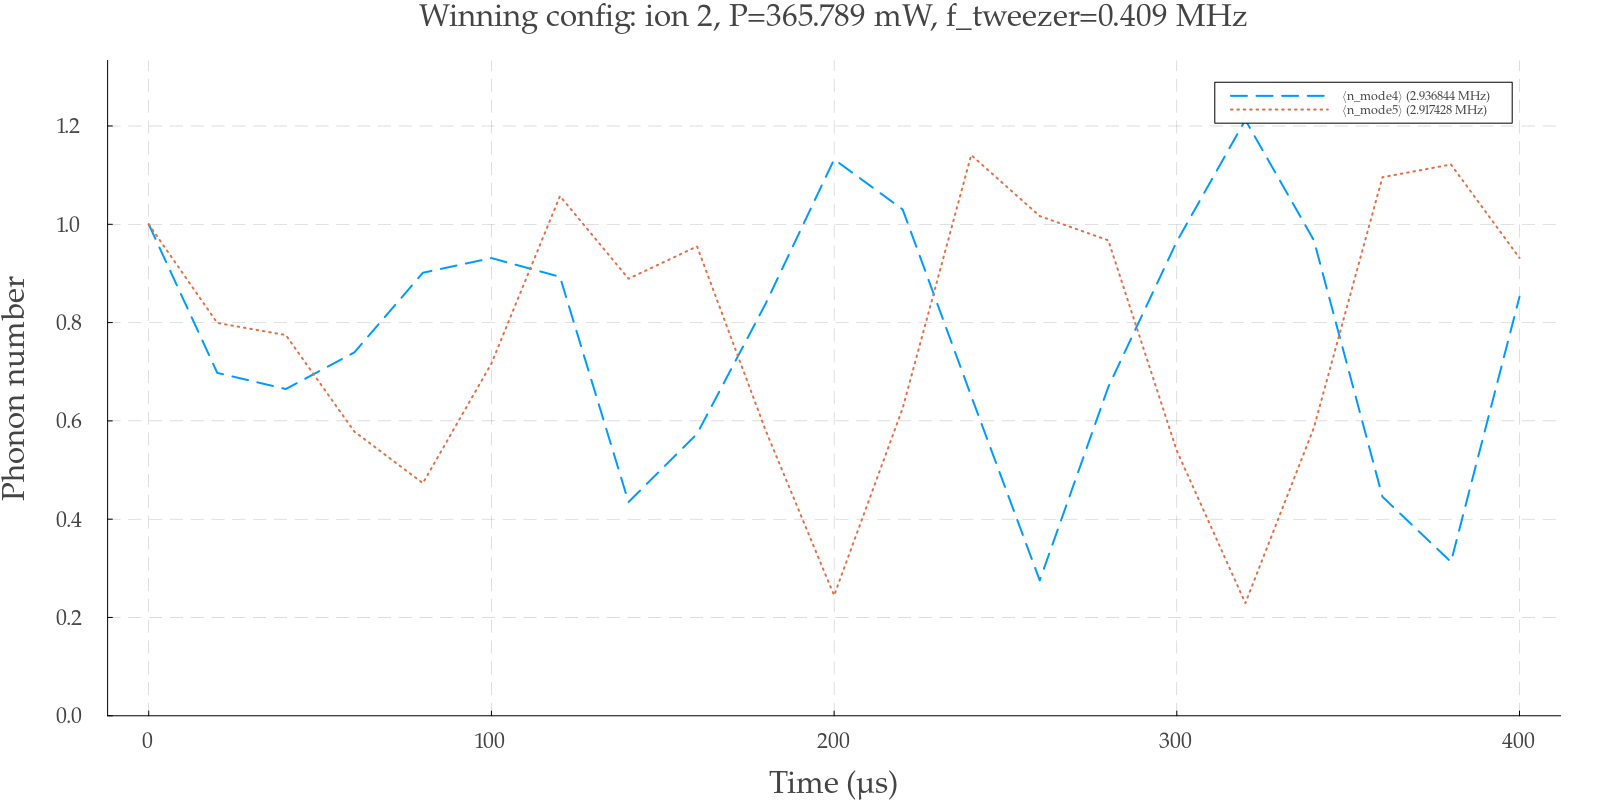

In [79]:
sweep_results_ion2, winner_ion2 = sweep_tweezer_pipeline(2)

plt.plot(winner_ion2.result.tout, winner_ion2.result.n_A, ls="dashed",
    label="⟨n_mode$(winner_ion2.result.modeA_idx)⟩ ($(round(winner_ion2.result.freqA/1e6, digits=6)) MHz)")
plt.plot(winner_ion2.result.tout, winner_ion2.result.n_B, ls="dotted",
    label="⟨n_mode$(winner_ion2.result.modeB_idx)⟩ ($(round(winner_ion2.result.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
Plots.title!("Winning config: ion 2, P=$(round(winner_ion2.P*1e3, digits=3)) mW, f_tweezer=$(round(winner_ion2.f_tweezer/1e6, digits=4)) MHz")
plt.ylim(0, max(maximum(winner_ion2.result.n_A), maximum(winner_ion2.result.n_B)) * 1.1)
plt.show()

addressing ion 1 (spectator)
  mode 1  freq=3.007987 MHz  η=0.013378643114743249
  mode 2  freq=2.984962 MHz  η=-0.025364431139081864  <- driven
  mode 3  freq=2.97128 MHz  η=-0.02383315562789316  <- driven
  mode 4  freq=2.936844 MHz  η=-0.012061626736614713
  mode 5  freq=2.917319 MHz  η=0.006453802927087206


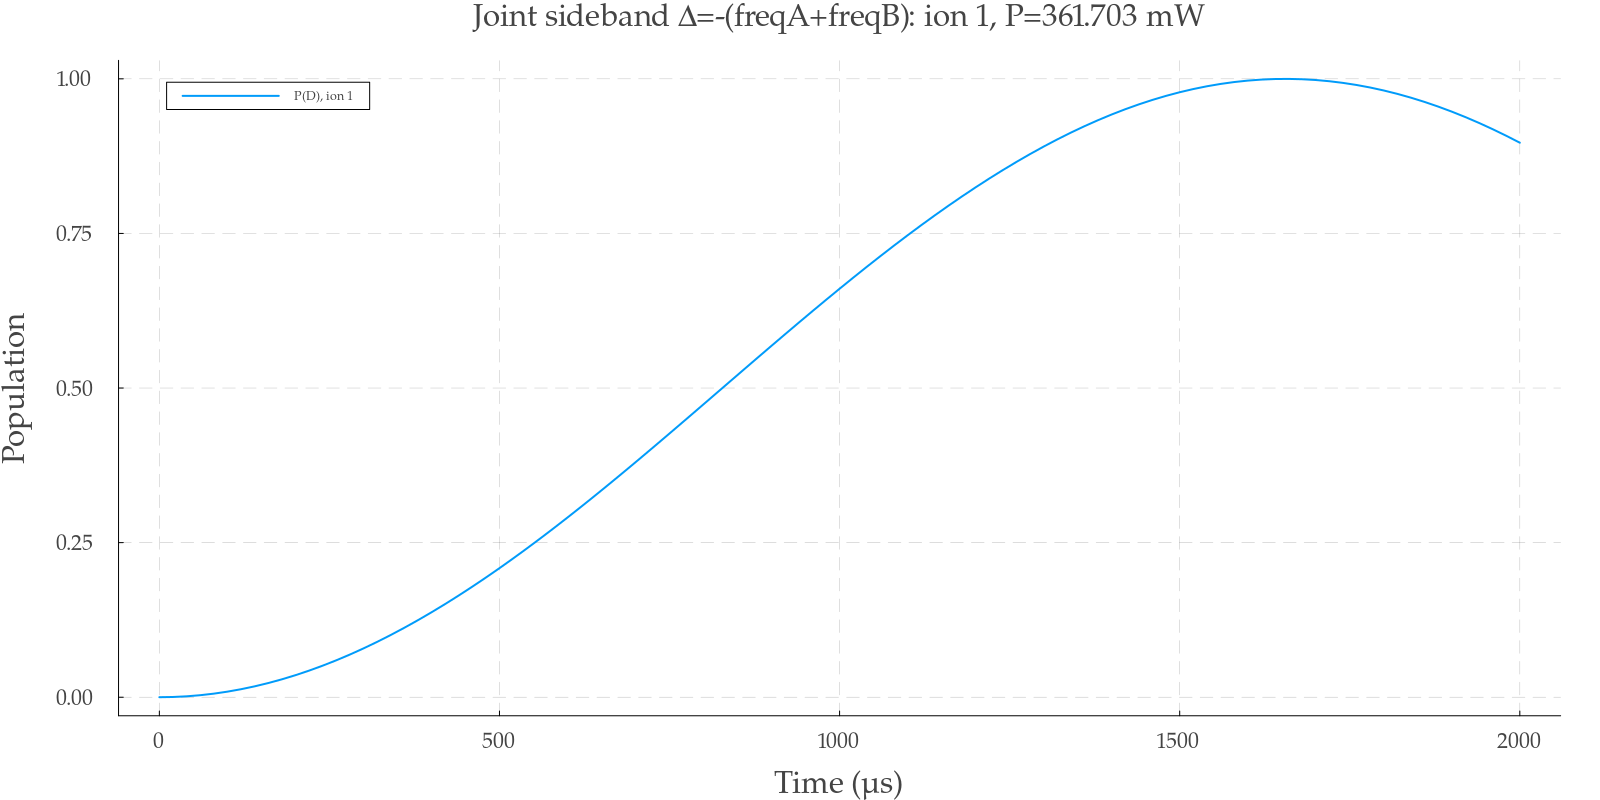

In [80]:
result_ion1_sum_pipeline = run_tweezer_pipeline(1; detuning_mode=:sum, tspan=0:20:2000)
plt.plot(result_ion1_sum_pipeline.tout, result_ion1_sum_pipeline.P_D, label="P(D), ion 1")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
Plots.title!("Joint sideband Δ=-(freqA+freqB): ion 1, P=$(round(P_pipeline*1e3, digits=3)) mW")
plt.show()

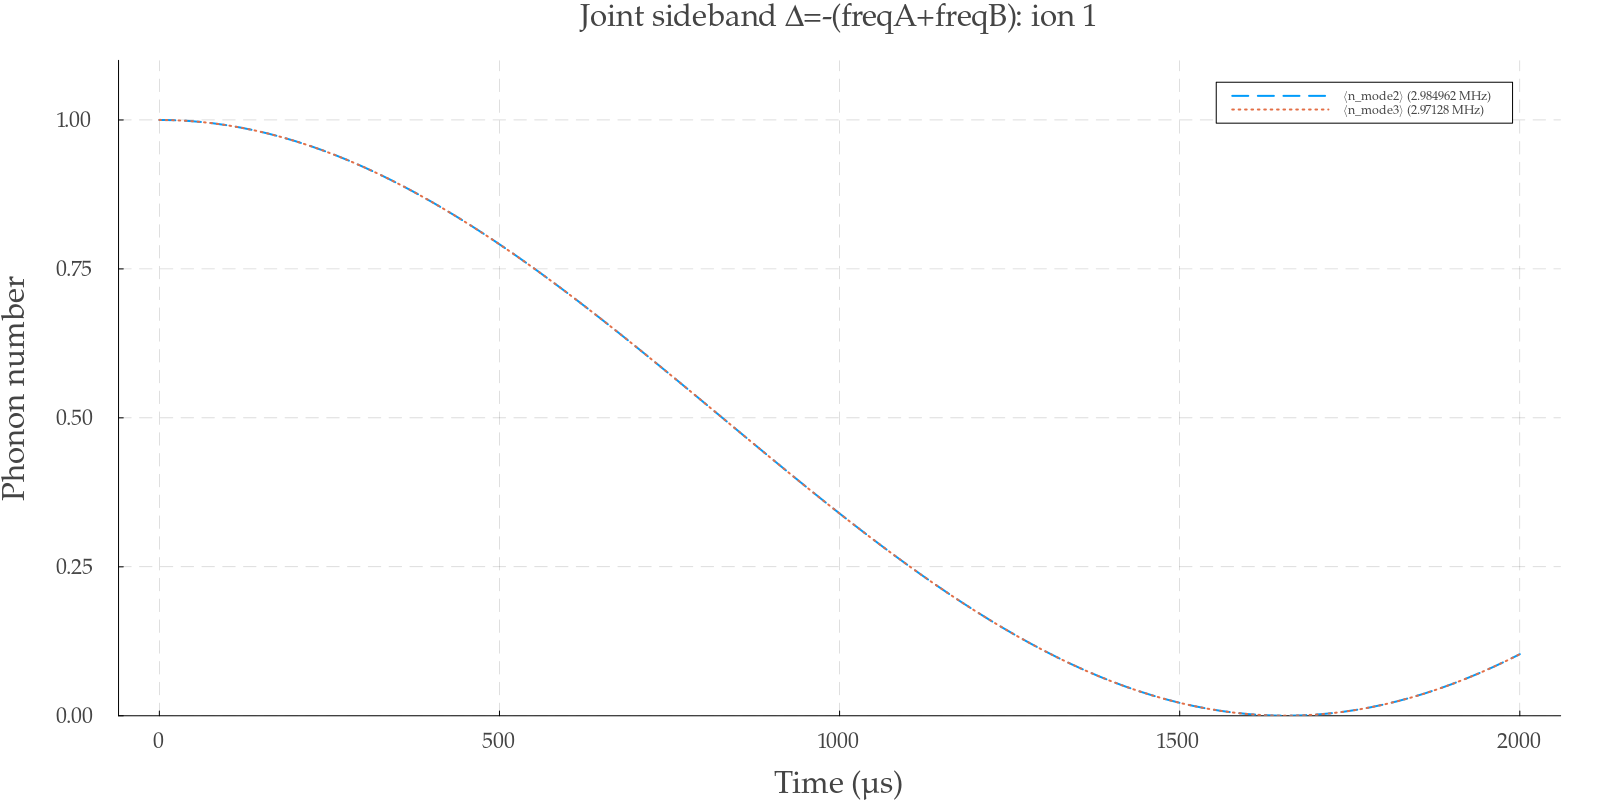

In [81]:
plt.plot(result_ion1_sum_pipeline.tout, result_ion1_sum_pipeline.n_A, ls="dashed",
    label="⟨n_mode$(result_ion1_sum_pipeline.modeA_idx)⟩ ($(round(result_ion1_sum_pipeline.freqA/1e6, digits=6)) MHz)")
plt.plot(result_ion1_sum_pipeline.tout, result_ion1_sum_pipeline.n_B, ls="dotted",
    label="⟨n_mode$(result_ion1_sum_pipeline.modeB_idx)⟩ ($(round(result_ion1_sum_pipeline.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
Plots.title!("Joint sideband Δ=-(freqA+freqB): ion 1")
plt.ylim(0, max(maximum(result_ion1_sum_pipeline.n_A), maximum(result_ion1_sum_pipeline.n_B)) * 1.1)
plt.show()

addressing ion 2 (spectator)
  mode 1  freq=3.007987 MHz  η=0.017078404321509363
  mode 2  freq=2.984962 MHz  η=-0.011964013733132915
  mode 3  freq=2.97128 MHz  η=0.0038254604158654347
  mode 4  freq=2.936844 MHz  η=0.025571376597239407  <- driven
  mode 5  freq=2.917319 MHz  η=-0.022115300990772326  <- driven


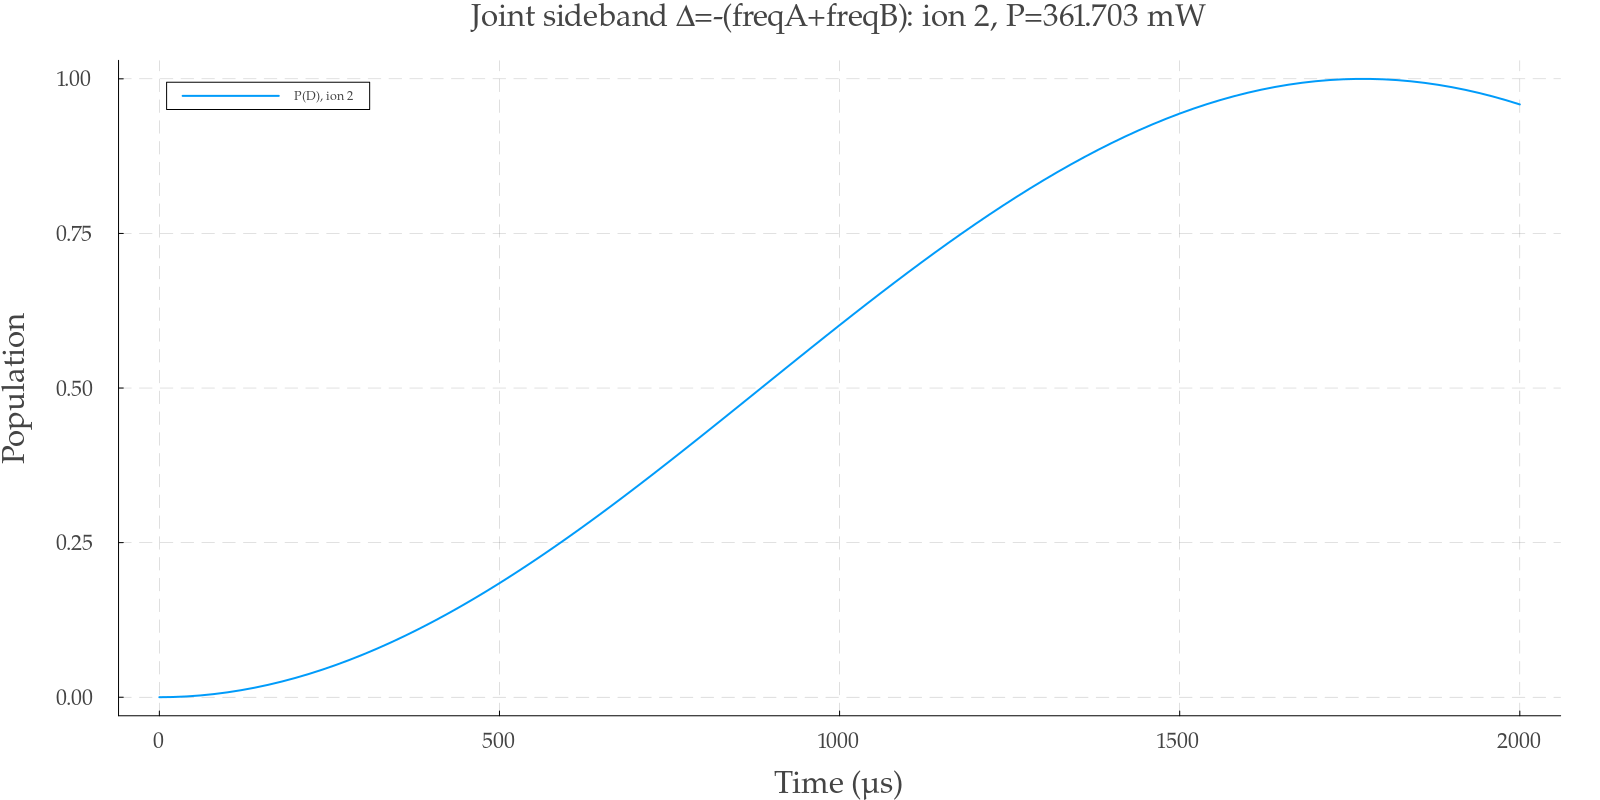

In [82]:
result_ion2_sum_pipeline = run_tweezer_pipeline(2; detuning_mode=:sum, tspan=0:20:2000)
plt.plot(result_ion2_sum_pipeline.tout, result_ion2_sum_pipeline.P_D, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
Plots.title!("Joint sideband Δ=-(freqA+freqB): ion 2, P=$(round(P_pipeline*1e3, digits=3)) mW")
plt.show()

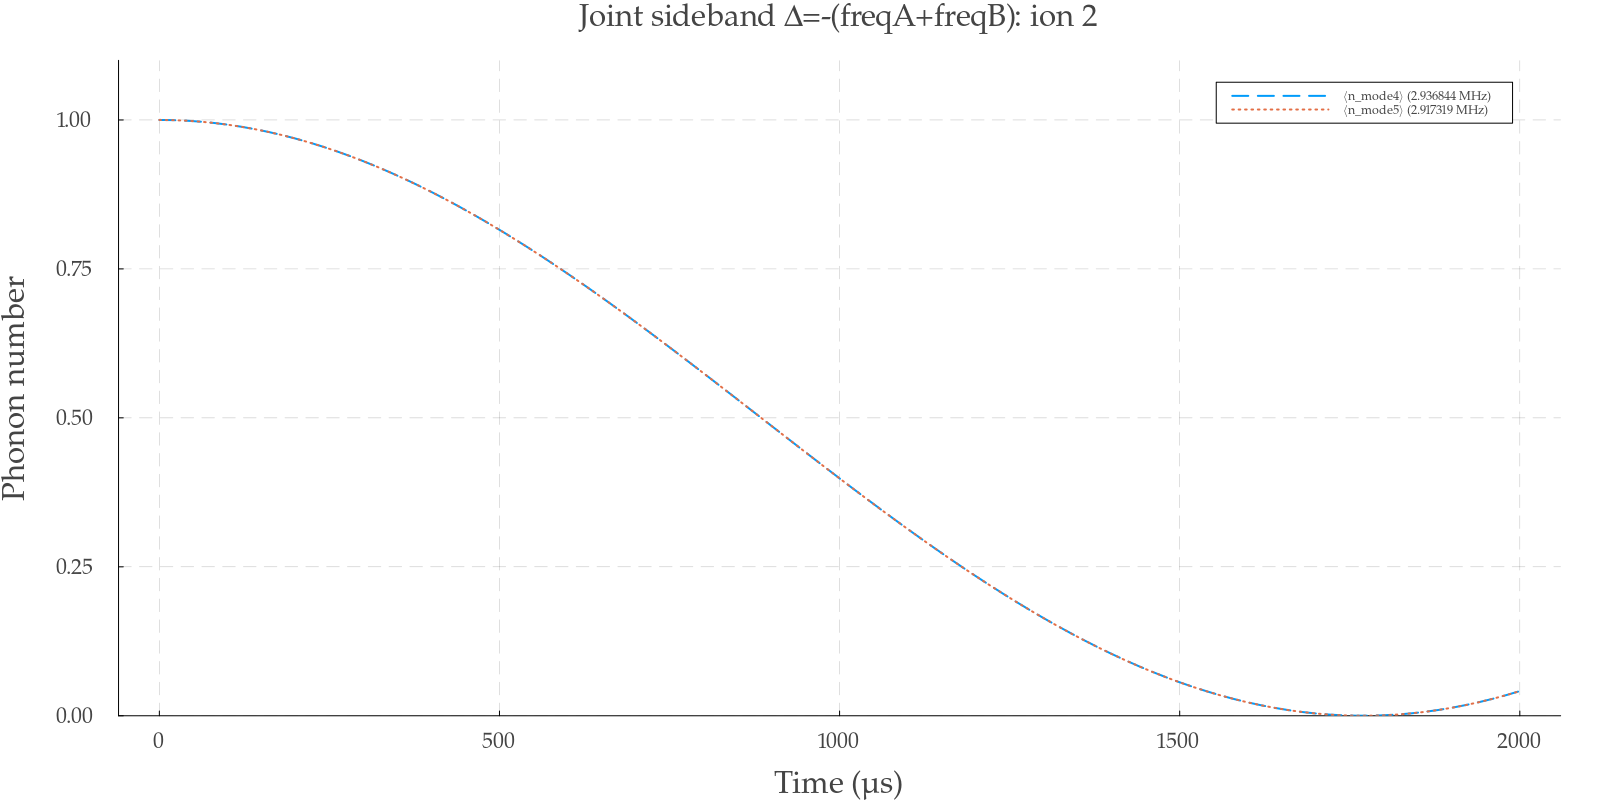

In [83]:
plt.plot(result_ion2_sum_pipeline.tout, result_ion2_sum_pipeline.n_A, ls="dashed",
    label="⟨n_mode$(result_ion2_sum_pipeline.modeA_idx)⟩ ($(round(result_ion2_sum_pipeline.freqA/1e6, digits=6)) MHz)")
plt.plot(result_ion2_sum_pipeline.tout, result_ion2_sum_pipeline.n_B, ls="dotted",
    label="⟨n_mode$(result_ion2_sum_pipeline.modeB_idx)⟩ ($(round(result_ion2_sum_pipeline.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.ylim(0, max(maximum(result_ion2_sum_pipeline.n_A), maximum(result_ion2_sum_pipeline.n_B)) * 1.1)
Plots.title!("Joint sideband Δ=-(freqA+freqB): ion 2")
plt.show()

P=50.0 mW   f_tweezer=0.1512 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=89.474 mW   f_tweezer=0.2023 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0
P=128.947 mW   f_tweezer=0.2428 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0
P=168.421 mW   f_tweezer=0.2775 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0
P=207.895 mW   f_tweezer=0.3083 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=247.368 mW   f_tweezer=0.3363 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0
P=286.842 mW   f_tweezer=0.3622 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0
P=326.316 mW   f_tweezer=0.3863 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=365.789 mW   f_tweezer=0.409 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=405.263 mW   f_tweezer=0.4305 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=444.737 mW   f_tweezer=0.451 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=484.211 mW   f_tweezer=0.4706 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=523.684 mW   f_tweezer=0.4894 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=563.158 mW   f_tweezer=0.5075 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=602.632 mW   f_tweezer=0.525 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=642.105 mW   f_tweezer=0.5419 MHz   min(⟨n_A⟩,⟨n_B⟩)=0.0001
P=681.579 mW   f_tweezer=0.558

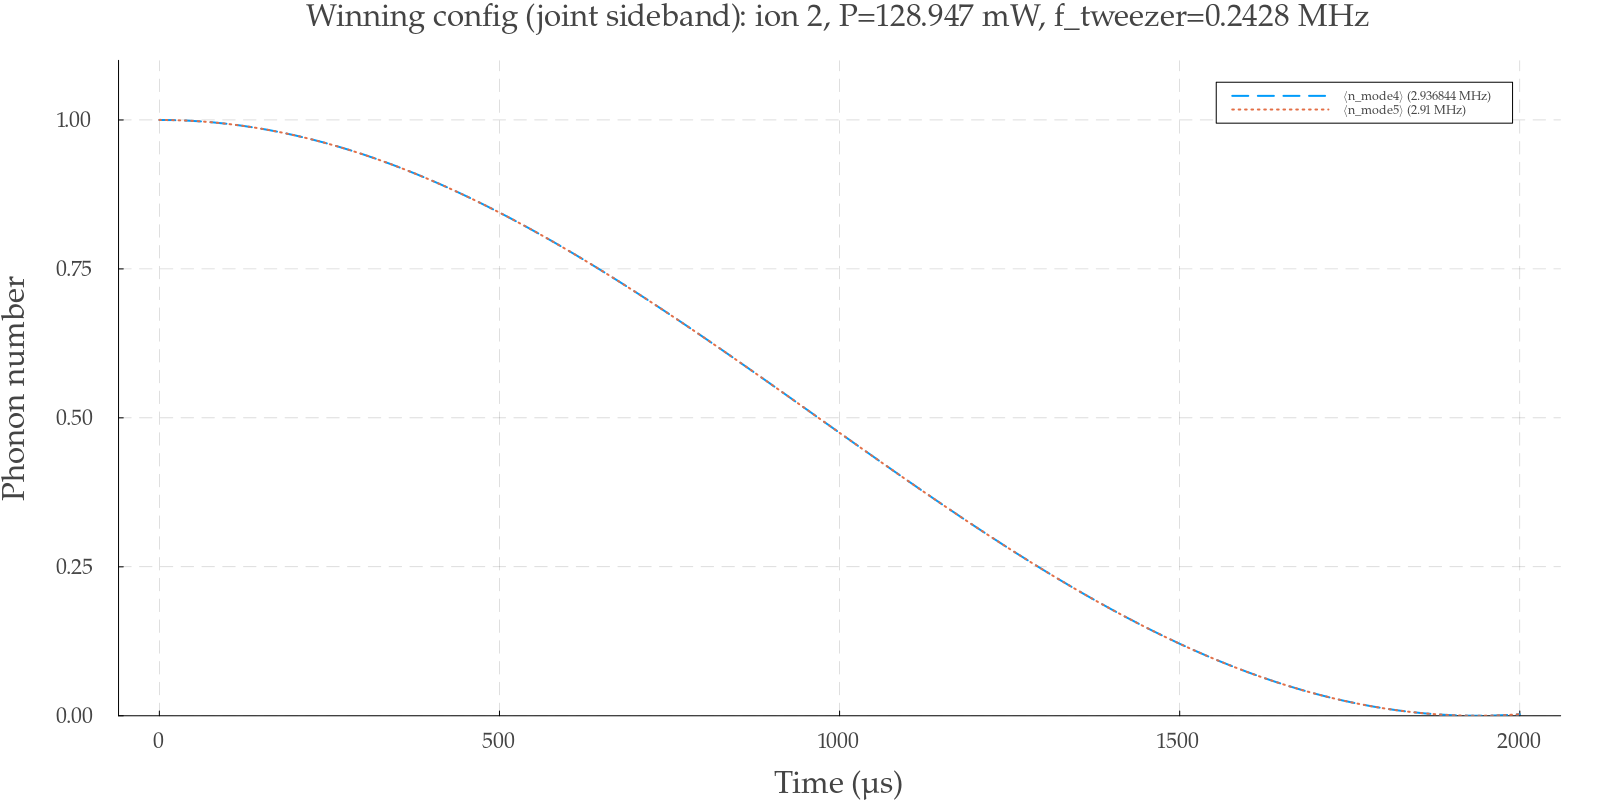

In [84]:
sweep_results_ion2_sum, winner_ion2_sum = sweep_tweezer_pipeline(2; detuning_mode=:sum, tspan=0:20:2000)

plt.plot(winner_ion2_sum.result.tout, winner_ion2_sum.result.n_A, ls="dashed",
    label="⟨n_mode$(winner_ion2_sum.result.modeA_idx)⟩ ($(round(winner_ion2_sum.result.freqA/1e6, digits=6)) MHz)")
plt.plot(winner_ion2_sum.result.tout, winner_ion2_sum.result.n_B, ls="dotted",
    label="⟨n_mode$(winner_ion2_sum.result.modeB_idx)⟩ ($(round(winner_ion2_sum.result.freqB/1e6, digits=6)) MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
Plots.title!("Winning config (joint sideband): ion 2, P=$(round(winner_ion2_sum.P*1e3, digits=3)) mW, f_tweezer=$(round(winner_ion2_sum.f_tweezer/1e6, digits=4)) MHz")
plt.ylim(0, max(maximum(winner_ion2_sum.result.n_A), maximum(winner_ion2_sum.result.n_B)) * 1.1)
plt.show()